In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.calibration import CalibratedClassifierCV  # Added for calibration
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

import splitflow.TripletLoss as CCL
from splitflow.PlotUtilities import *
import splitflow.RFClassifier as RF
import figurefirst as fifi
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)


import gc
gc.collect()
#with tf.device('/cpu:2'):
#    gc.collect()

Using device: cpu


28

In [2]:

plt.rcParams['font.serif'] = ['Helvetica'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 6
plt.rcParams['text.usetex'] = False
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'

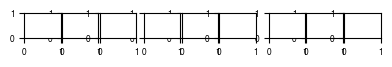

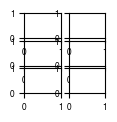

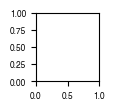

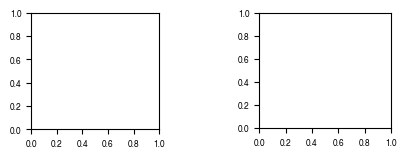

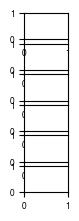

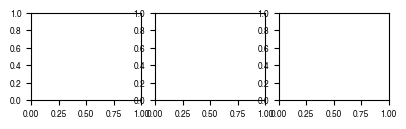

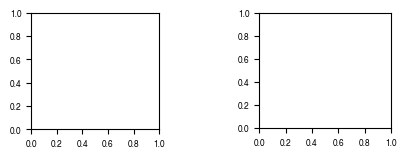

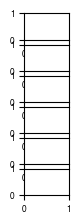

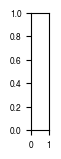

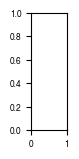

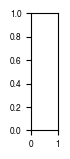

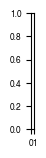

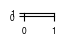

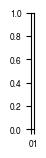

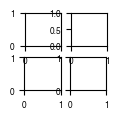

In [3]:
layout = fifi.svg_to_axes.FigureLayout('f4_template.svg',autogenlayers=True, make_mplfigures=True, hide_layers=[])

# Import Training Trajectories

In [4]:
middf = pd.read_hdf('../../../Data/Simulated_Trajectory_Data/training_sims_6_classes.hdf')
#print("Loading data...")

In [5]:
class_labels={
   0: 'Casting Sim', 
    1: 'Circling Sim',
    2:  'random turns',
    3: 'brownian', 
    4:'levy flight',
    5:'run and tumble'
}

In [6]:
middf.loc[middf.dataset_name=='Casting Sim','color'] = 'orangered'
middf.loc[middf.dataset_name=='Circling Sim','color'] = 'darkcyan' 
middf.loc[middf.dataset_name=='run and tumble','color'] = 'darkviolet'
middf.loc[middf.dataset_name=='levysmooth','color'] = 'yellow'
middf.loc[middf.dataset_name=='150ms_to_450ms_random_turns','color'] = 'orchid'
middf.loc[middf.dataset_name=='brownian','color'] = 'lime'



In [7]:


trajectories = np.array([
    group[['x', 'y','xvel','yvel' ]].values 
    for _, group in middf[ (middf['time stamp'].between(1100,3000))].sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])
        
print(f"Result shape: {trajectories.shape}")

labels = middf.groupby('obj_id_unique').first()['dataset_numeric'].values

obj_id_values = middf.groupby('obj_id_unique').first().index

print(f"Trajectories shape: {trajectories.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Number of classes: {len(np.unique(labels))}")

Result shape: (60000, 191, 4)
Trajectories shape: (60000, 191, 4)
Labels shape: (60000,)
Number of classes: 6


In [8]:

print(f"Trajectories shape: {trajectories.shape}")  # Should be (1500, 200, 4)
print(f"Features: [x, y, xvel, yvel]")
print(f"Labels shape: {labels.shape}")
num_clusters=len(np.unique(labels))


#obj_id_values =  middf.groupby('obj_id_unique').first().index#.values

#color_values = middf.groupby('obj_id_unique').first()['color']

obj_id_values = middf.groupby('obj_id_unique').first().index.to_numpy()
color_values = middf.groupby('obj_id_unique').first()['color'].to_numpy()
#color_values =  middf[(middf['obj_id_unique'].isin(subsample_ids ))].groupby('obj_id_unique').first()['color']#middf.groupby('obj_id_unique').first()['color']





# Split data
X_train, X_test, y_train, y_test,obj_train, obj_test, color_train,color_test = train_test_split(
    trajectories, labels, obj_id_values, color_values, test_size=0.2, random_state=42, stratify=labels
)

print(X_train.shape[0])

# Create datasets and dataloaders
train_dataset = CCL.TrajectoryDataset(X_train, y_train, obj_train, normalization_type='zero_mean')
test_dataset = CCL.TrajectoryDataset(X_test, y_test, obj_test, normalization_type='zero_mean')

train_loader = CCL.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = CCL.DataLoader(test_dataset, batch_size=128, shuffle=False)
# Initialize and train Clustering VAE
print("Training Clustering VAE with cluster-center loss...")



input_dim = X_train.shape[1] * X_train.shape[2]  # 191 * 4 = 764

num_clusters = len(np.unique(labels))


print(f"Input dimension: {input_dim}")
print(f"Number of clusters: {num_clusters}")

Trajectories shape: (60000, 191, 4)
Features: [x, y, xvel, yvel]
Labels shape: (60000,)
48000
Training Clustering VAE with cluster-center loss...
Input dimension: 764
Number of clusters: 6


# Load in model

In [9]:
triplet_model = CCL.TripletLossVAE(input_dim=input_dim, hidden_dim=540, latent_dim=70, margin=1.5)
triplet_model.load_state_dict(torch.load("triplet_vae_6_classes_70_feats.pth"))

<All keys matched successfully>

## alternatively: train model

In [10]:
# train 


triplet_model1 = CCL.TripletLossVAE(input_dim=input_dim, hidden_dim=540, latent_dim=70, margin=1.5)

print(f"Model has {sum(p.numel() for p in triplet_model.parameters()):,} parameters")

# Train with triplet loss
train_losses, val_losses, triplet_losses, val_triplet_losses, kl_losses, val_kl_losses = CCL.train_vae_with_triplet(
    triplet_model1, train_loader, test_loader, epochs=250, triplet_weight=0.2
)

Model has 1,224,544 parameters


Epoch 000:
  Train - Total: 0.514315, VAE: 0.331151, Triplet: 0.915818, KL: 0.336840
  Val   - Total: 0.352449, VAE: 0.263326, Triplet: 0.445612, KL: 0.576130 



Epoch 020:
  Train - Total: 0.130958, VAE: 0.119748, Triplet: 0.056051, KL: 2.824476
  Val   - Total: 0.117302, VAE: 0.105045, Triplet: 0.061281, KL: 2.913307 



Epoch 040:
  Train - Total: 0.117403, VAE: 0.110898, Triplet: 0.032523, KL: 2.929005
  Val   - Total: 0.105289, VAE: 0.097763, Triplet: 0.037626, KL: 2.988269 



Epoch 060:
  Train - Total: 0.112979, VAE: 0.108313, Triplet: 0.023331, KL: 2.866156
  Val   - Total: 0.102561, VAE: 0.095705, Triplet: 0.034283, KL: 2.903170 



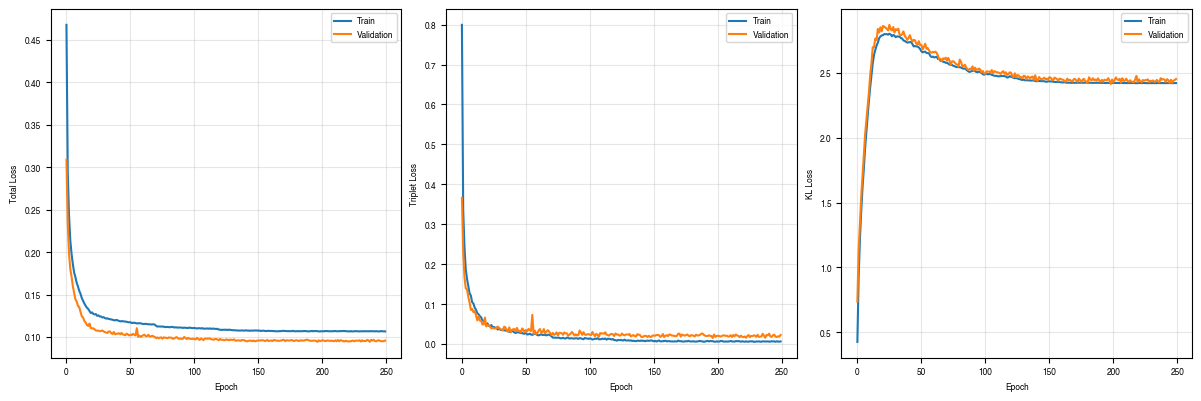

In [195]:
# View Losses
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(triplet_losses, label='Train')
plt.plot(val_triplet_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Triplet Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(kl_losses, label='Train')
plt.plot(val_kl_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('KL Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [201]:
# --- 2. corrected diagnostic (note np.diff(out, axis=0), fixing my earlier bug) ---
def gmm_centroid(gmm):
    return gmm.weights_ @ gmm.means_   # weighted mean of GMM components

def interp_diagnostic(model, gmm_models, class_a, class_b, n=25, n_feats=4):
    model.eval()
    cA = torch.tensor(gmm_centroid(gmm_models[str(class_a)]), dtype=torch.float32)
    cB = torch.tensor(gmm_centroid(gmm_models[str(class_b)]), dtype=torch.float32)
    t  = torch.linspace(0, 1, n).unsqueeze(1)
    Z  = (1 - t) * cA + t * cB
    with torch.no_grad():
        out = model.decode(Z).cpu().numpy()          # (n, 764)
    trajs = out.reshape(n, -1, n_feats)[:, :, 0:2]
    tt = np.linspace(0, 1, n)

    # (1) decoded morph
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in range(n):
        ax.plot(trajs[i, :, 0], trajs[i, :, 1], color=plt.cm.viridis(tt[i]), alpha=.7)
    ax.set_aspect('equal'); ax.set_title(f'{class_a} -> {class_b}'); plt.show()

    # (2) THE GAP TEST: latent density along the path
    plt.figure(figsize=(7, 4))
    lls = []
    for c, gm in gmm_models.items():
        ll = gm.score_samples(Z.numpy()); lls.append(ll)
        plt.plot(tt, ll, alpha=.5, label=f'class {c}')
    plt.plot(tt, np.max(lls, 0), 'k--', lw=2, label='max over classes')
    plt.xlabel('t'); plt.ylabel('GMM log-likelihood'); plt.legend()
    plt.title('Density along path - a deep mid-path dip = a gap'); plt.show()

    # (3) abruptness: output-space speed
    speed = np.linalg.norm(np.diff(out, axis=0), axis=1)
    plt.figure(figsize=(7, 3)); plt.plot(tt[1:], speed)
    plt.xlabel('t'); plt.ylabel('||delta decode||')
    plt.title('Output speed - a spike = abrupt transition'); plt.show()

    return Z, trajs

In [200]:
# --- 0. make sure the model is in eval mode (BatchNorm uses running stats, not batch stats) ---
triplet_model1.eval()

# --- 1. fit the per-class GMMs on the latent means of the labeled training data ---
results = CCL.sample_from_aggregated_posterior(
    triplet_model1,
    train_loader,            # the labeled 6-class simulation loader you trained on
    device='cpu',
    plot_results=False,      # skip the function's own plots; we only need the GMMs
    generate_examples=False, # skip decoder-sample generation; not needed for centroids
)

# confirm the GMM dict is keyed by string labels '0','1',... as the diagnostic expects
print(list(results['gmm_models'].keys()))

Fitting Gaussian Mixture Models...
  Class 2: 8000 samples, using 10 GMM components
  Class 4: 8000 samples, using 10 GMM components
  Class 3: 8000 samples, using 10 GMM components
  Class 5: 8000 samples, using 10 GMM components
  Class 0: 8000 samples, using 10 GMM components
  Class 1: 8000 samples, using 10 GMM components
Generating samples from decoder...
['2', '4', '3', '5', '0', '1']


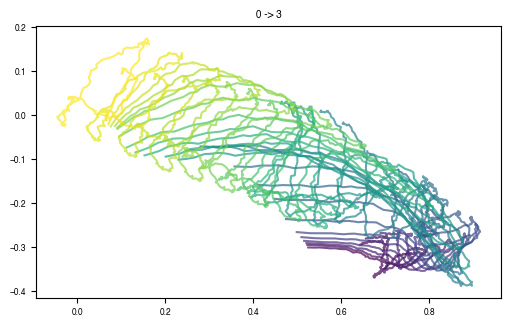

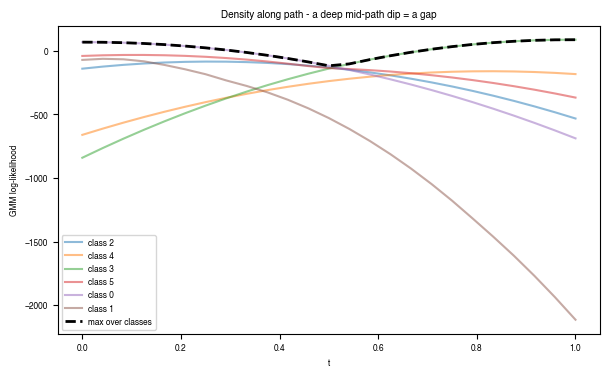

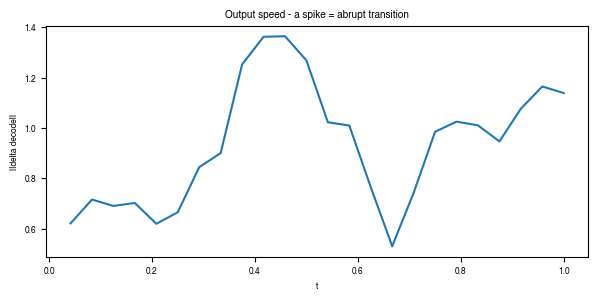

In [203]:
# --- 3. run it on the casting (0) -> circling (1) path ---
Z, trajs = interp_diagnostic(
    model=triplet_model1,
    gmm_models=results['gmm_models'],
    class_a=0,   # Casting Sim, per your class_labels dict
    class_b=3,   # Circling Sim
    n=25,
)

In [ ]:
triplet_model.eval()
    # Define the path to save the model
PATH = "triplet_vae_6_classes_70_feats.pth"

# Save the state_dict
torch.save(triplet_model.state_dict(), PATH)

# Load in the various fly datasets

### all c1xwt split flow data

In [10]:
bottom_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/all_nights_new_processing_protocol_bottom_laminar_09092024.hdf')
bottom_on_df['dataset_numeric'] = 100
bottom_on_df['ground speed']= np.sqrt(bottom_on_df.xvel**2 + bottom_on_df.yvel**2)
#bottom_on_df = bottom_on_df#.groupby("obj_id_unique").filter(lambda d: (d['ground speed'].mean()>.15)& (d['time stamp'].max()>=3000))
#bottom_on_df= bottom_on_df[bottom_on_df['time stamp'].between(1100,3000)]

df_flash_bottom_on = bottom_on_df[bottom_on_df.duration>0].groupby("obj_id_unique").filter(lambda d: (d['ground speed'].mean()>.15)& (d['time stamp'].max()>=3000))

df_sham_bottom_on =bottom_on_df[bottom_on_df.duration==0].groupby("obj_id_unique").filter(lambda d: (d['ground speed'].mean()>.15)& (d['time stamp'].max()>=3000))



flash_low_bottom_on = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_bottom_on  = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

sham_low_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)





In [11]:


top_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/all_nights_new_processing_protocol_top_laminar_09082024.hdf')
top_on_df['ground speed']= np.sqrt(top_on_df.xvel**2 + top_on_df.yvel**2)
#top_on_df = bottom_on_df#.groupby("obj_id_unique").filter(lambda d: (d['ground speed'].mean()>.15)& (d['time stamp'].max()>=3000))
#bottom_on_df= bottom_on_df[bottom_on_df['time stamp'].between(1100,3000)]
top_on_df['dataset_numeric'] = 100

df_flash_top_on = top_on_df[top_on_df.duration>0].groupby("obj_id_unique").filter(lambda d: (d['ground speed'].mean()>.15) & (d['time stamp'].max()>=3000))

df_sham_top_on =top_on_df[top_on_df.duration==0].groupby("obj_id_unique").filter(lambda d:(d['ground speed'].mean()>.15) &  (d['time stamp'].max()>=3000))



flash_low_top_on = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_top_on  = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

sham_low_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)



In [12]:
cmap_real = plt.get_cmap('RdBu', 16) 

flash_low_bottom_on['color'] = 'darkorange'
flash_up_bottom_on['color'] = [cmap_real(11)] * len(flash_up_bottom_on)
flash_low_top_on['color'] = [cmap_real(13)] * len(flash_low_top_on)
flash_up_top_on['color'] = [cmap_real(3)] * len(flash_up_top_on)



flash_low_bottom_on['dataset_name'] = 'Steady, z<.25'
flash_up_bottom_on['dataset_name'] = 'Unsteady, z>.25'
flash_low_top_on['dataset_name'] = 'Unsteady, z<.25'
flash_up_top_on['dataset_name'] = 'Steady, z>.25'



In [13]:
cmap_real = plt.get_cmap('RdBu', 16) 

sham_low_bottom_on['color'] = 'darkorange'
sham_up_bottom_on['color'] = [cmap_real(11)] * len(sham_up_bottom_on)
sham_low_top_on['color'] = [cmap_real(13)] * len(sham_low_top_on)
sham_up_top_on['color'] = [cmap_real(3)] * len(sham_up_top_on)



sham_low_bottom_on['dataset_name'] = 'Sham Steady, z<.25'
sham_up_bottom_on['dataset_name'] = 'Sham Unsteady, z>.25'
sham_low_top_on['dataset_name'] = 'Sham Unsteady, z<.25'
sham_up_top_on['dataset_name'] = 'Sham Steady, z>.25'



In [14]:
c1xwt_flash = pd.concat([flash_low_bottom_on,flash_up_bottom_on,flash_low_top_on,flash_up_top_on])
c1xwt_sham = pd.concat([sham_low_bottom_on,sham_up_bottom_on,sham_low_top_on,sham_up_top_on])

In [15]:
c1xwt_flash['dataset_numeric'] = pd.factorize(c1xwt_flash['dataset_name'])[0]

### Split Flow -- Flash

In [156]:
c1xwt_flash =pd.concat([flash_low_top_on,])#flash_up_bottom_on ])

### transform the array & labels correctly

unsteady_array = np.array([
    group[['x', 'y', 'xvel', 'yvel', ]].values 
    for _, group in c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {unsteady_array.shape}")

# get labels
unsteady_labels = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['dataset_numeric'].to_numpy()#.values

unsteady_objids = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first().index.to_numpy()#.values

print(f"Updated labels shape: {unsteady_labels.shape}")



unsteady_color =  c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']

# c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique')['z'].quantile(.90).rename('Mean_z_after_odor')
 #c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']#.values




# Now split while maintaining correspondence
X_train_unsteady, X_test_unsteady, y_train_unsteady, y_test_unsteady, y_train_unsteady_color, y_test_unsteady_color,y_train_unsteady_obj, y_test_unsteady_obj   = train_test_split(
#X_train_split_flash_bottom_on, X_test_split_flash_bottom_on, y_train_split_flash_bottom_on, y_test_split_flash_bottom_on,  = train_test_split(

    unsteady_array, 
    unsteady_labels, 
    unsteady_color,
    unsteady_objids, # Include color variable in split
    test_size=0.01, 
    random_state=44, 
    stratify=unsteady_labels
)

# Create datasets and dataloaders
train_dataset_unsteady = CCL.TrajectoryDataset(X_train_unsteady, y_train_unsteady,y_train_unsteady_obj,  normalization_type='zero_mean')
test_dataset_unsteady = CCL.TrajectoryDataset(X_test_unsteady, y_test_unsteady,y_test_unsteady_obj,  normalization_type='zero_mean')

train_loader_unsteady = CCL.DataLoader(train_dataset_unsteady, batch_size=32, shuffle=True)
test_loader_unsteady = CCL.DataLoader(test_dataset_unsteady, batch_size=32, shuffle=False)

Result shape: (90, 191, 4)
Updated labels shape: (90,)


In [17]:
c1xwt_flash =pd.concat([flash_low_top_on,])#flash_up_bottom_on ])

### transform the array & labels correctly

unsteady_array = np.array([
    group[['x', 'y', 'xvel', 'yvel', ]].values 
    for _, group in c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {unsteady_array.shape}")

# get labels
unsteady_labels = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['dataset_numeric'].to_numpy()#.values

unsteady_objids = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first().index.to_numpy()#.values

print(f"Updated labels shape: {unsteady_labels.shape}")



unsteady_color =  c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']

# c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique')['z'].quantile(.90).rename('Mean_z_after_odor')
 #c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']#.values




# Now split while maintaining correspondence
X_train_unsteady, X_test_unsteady, y_train_unsteady, y_test_unsteady, y_train_unsteady_color, y_test_unsteady_color,y_train_unsteady_obj, y_test_unsteady_obj   = train_test_split(
#X_train_split_flash_bottom_on, X_test_split_flash_bottom_on, y_train_split_flash_bottom_on, y_test_split_flash_bottom_on,  = train_test_split(

    unsteady_array, 
    unsteady_labels, 
    unsteady_color,
    unsteady_objids, # Include color variable in split
    test_size=0.01, 
    random_state=42, 
    stratify=unsteady_labels
)

# Create datasets and dataloaders
train_dataset_unsteady = CCL.TrajectoryDataset(X_train_unsteady, y_train_unsteady,y_train_unsteady_obj,  normalization_type='zero_mean')
test_dataset_unsteady = CCL.TrajectoryDataset(X_test_unsteady, y_test_unsteady,y_test_unsteady_obj,  normalization_type='zero_mean')

train_loader_unsteady = CCL.DataLoader(train_dataset_unsteady, batch_size=32, shuffle=True)
test_loader_unsteady = CCL.DataLoader(test_dataset_unsteady, batch_size=32, shuffle=False)

Result shape: (90, 191, 4)
Updated labels shape: (90,)


In [18]:
c1xwt_flash = pd.concat([flash_low_top_on,])

unsteady_array = np.array([
    group[['x', 'y', 'xvel', 'yvel']].values
    for _, group in c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {unsteady_array.shape}")

unsteady_labels = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['dataset_numeric'].to_numpy()
unsteady_objids = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first().index.to_numpy()
unsteady_color  = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color'].to_numpy()

print(f"Updated labels shape: {unsteady_labels.shape}")

# Use full dataset as training set (no test split)
X_train_unsteady        = unsteady_array
y_train_unsteady        = unsteady_labels
y_train_unsteady_color  = unsteady_color
y_train_unsteady_obj    = unsteady_objids
X_test_unsteady         = unsteady_array
y_test_unsteady         = unsteady_labels
y_test_unsteady_color   = unsteady_color
y_test_unsteady_obj     = unsteady_objids

# Create datasets and dataloaders
train_dataset_unsteady = CCL.TrajectoryDataset(X_train_unsteady, y_train_unsteady, y_train_unsteady_obj, normalization_type='zero_mean')
test_dataset_unsteady  = CCL.TrajectoryDataset(X_test_unsteady,  y_test_unsteady,  y_test_unsteady_obj,  normalization_type='zero_mean')

train_loader_unsteady = CCL.DataLoader(train_dataset_unsteady, batch_size=32, shuffle=True)
test_loader_unsteady  = CCL.DataLoader(test_dataset_unsteady,  batch_size=32, shuffle=False)


Result shape: (90, 191, 4)
Updated labels shape: (90,)


In [19]:
c1xwt_flash.obj_id_unique.nunique()

90

In [20]:
c1xwt_flash = flash_low_bottom_on#pd.concat([flash_low_bottom_on,flash_up_top_on ])

### transform the array & labels correctly

steady_array = np.array([
    group[['x', 'y', 'xvel', 'yvel', ]].values 
    for _, group in c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {steady_array.shape}")

# get labels
steady_labels = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['dataset_numeric'].to_numpy()#.values

steady_objids = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first().index.to_numpy()#.values

print(f"Updated labels shape: {steady_labels.shape}")



steady_color =  c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']

# c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique')['z'].quantile(.90).rename('Mean_z_after_odor')
 #c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']#.values




# Now split while maintaining correspondence
X_train_steady, X_test_steady, y_train_steady, y_test_steady, y_train_steady_color, y_test_steady_color,y_train_steady_obj, y_test_steady_obj   = train_test_split(
#X_train_split_flash_bottom_on, X_test_split_flash_bottom_on, y_train_split_flash_bottom_on, y_test_split_flash_bottom_on,  = train_test_split(

    steady_array, 
    steady_labels, 
    steady_color,
    steady_objids, # Include color variable in split
    test_size=0.01, 
    random_state=42, 
    stratify=steady_labels
)

# Create datasets and dataloaders
train_dataset_steady = CCL.TrajectoryDataset(X_train_steady, y_train_steady,obj_ids=y_train_steady_obj,  normalization_type='zero_mean')
test_dataset_steady = CCL.TrajectoryDataset(X_test_steady, y_test_steady,obj_ids=y_test_steady_obj,  normalization_type='zero_mean')

train_loader_steady = CCL.DataLoader(train_dataset_steady, batch_size=32, shuffle=True)
test_loader_steady = CCL.DataLoader(test_dataset_steady, batch_size=32, shuffle=False)

Result shape: (145, 191, 4)
Updated labels shape: (145,)


In [21]:
c1xwt_flash = flash_low_bottom_on

steady_array = np.array([
    group[['x', 'y', 'xvel', 'yvel']].values
    for _, group in c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {steady_array.shape}")

steady_labels = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['dataset_numeric'].to_numpy()
steady_objids = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first().index.to_numpy()
steady_color  = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color'].to_numpy()

print(f"Updated labels shape: {steady_labels.shape}")

# Use full dataset as training set (no test split)
X_train_steady        = steady_array
y_train_steady        = steady_labels
y_train_steady_color  = steady_color
y_train_steady_obj    = steady_objids
X_test_steady         = steady_array
y_test_steady         = steady_labels
y_test_steady_color   = steady_color
y_test_steady_obj     = steady_objids

# Create datasets and dataloaders
train_dataset_steady = CCL.TrajectoryDataset(X_train_steady, y_train_steady, obj_ids=y_train_steady_obj, normalization_type='zero_mean')
test_dataset_steady  = CCL.TrajectoryDataset(X_test_steady,  y_test_steady,  obj_ids=y_test_steady_obj,  normalization_type='zero_mean')

train_loader_steady = CCL.DataLoader(train_dataset_steady, batch_size=32, shuffle=True)
test_loader_steady  = CCL.DataLoader(test_dataset_steady,  batch_size=32, shuffle=False)

Result shape: (145, 191, 4)
Updated labels shape: (145,)


### Split flow -- shams

In [22]:
c1xwt_flash =pd.concat([sham_low_top_on,sham_up_bottom_on ])

### transform the array & labels correctly

sham_unsteady_array = np.array([
    group[['x', 'y', 'xvel', 'yvel', ]].values 
    for _, group in c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {sham_unsteady_array.shape}")

# get labels
sham_unsteady_labels = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['dataset_numeric'].to_numpy()#.values

sham_unsteady_objids = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first().index.to_numpy()#.values

print(f"Updated labels shape: {sham_unsteady_labels.shape}")



sham_unsteady_color =  c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color'].to_numpy()

# c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique')['z'].quantile(.90).rename('Mean_z_after_odor')
 #c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']#.values




# Now split while maintaining correspondence
X_train_unsteady_sham, X_test_unsteady_sham, y_train_unsteady_sham, y_test_unsteady_sham, y_train_unsteady_sham_color, y_test_unsteady_sham_color,y_train_unsteady_sham_obj, y_test_unsteady_sham_obj   = train_test_split(
#X_train_split_flash_bottom_on, X_test_split_flash_bottom_on, y_train_split_flash_bottom_on, y_test_split_flash_bottom_on,  = train_test_split(

    sham_unsteady_array, 
    sham_unsteady_labels, 
    sham_unsteady_color,
    sham_unsteady_objids, # Include color variable in split
    test_size=0.01, 
    random_state=42, 
    stratify=sham_unsteady_labels
)

# Create datasets and dataloaders
train_dataset_unsteady_sham = CCL.TrajectoryDataset(X_train_unsteady_sham, y_train_unsteady_sham,y_train_unsteady_sham_obj,  normalization_type='zero_mean')
test_dataset_unsteady_sham = CCL.TrajectoryDataset(X_test_unsteady_sham, y_test_unsteady_sham,y_test_unsteady_sham_obj,  normalization_type='zero_mean')

train_loader_unsteady_sham = CCL.DataLoader(train_dataset_unsteady_sham, batch_size=32, shuffle=True)
test_loader_unsteady_sham = CCL.DataLoader(test_dataset_unsteady_sham, batch_size=32, shuffle=False)

Result shape: (1737, 191, 4)
Updated labels shape: (1737,)


In [23]:
c1xwt_flash =pd.concat([sham_low_bottom_on,sham_up_top_on ])

### transform the array & labels correctly

sham_steady_array = np.array([
    group[['x', 'y', 'xvel', 'yvel', ]].values 
    for _, group in c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {sham_steady_array.shape}")

# get labels
sham_steady_labels = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['dataset_numeric'].to_numpy()#.values

sham_steady_objids = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first().index.to_numpy()#.values

print(f"Updated labels shape: {sham_steady_labels.shape}")



sham_steady_color =  c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']

# c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique')['z'].quantile(.90).rename('Mean_z_after_odor')
 #c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']#.values




# Now split while maintaining correspondence
X_train_steady_sham, X_test_steady_sham, y_train_steady_sham, y_test_steady_sham, y_train_steady_sham_color, y_test_steady_sham_color,y_train_steady_sham_obj, y_test_steady_sham_obj   = train_test_split(
#X_train_split_flash_bottom_on, X_test_split_flash_bottom_on, y_train_split_flash_bottom_on, y_test_split_flash_bottom_on,  = train_test_split(

    sham_steady_array, 
    sham_steady_labels, 
    sham_steady_color,
    sham_steady_objids, # Include color variable in split
    test_size=0.01, 
    random_state=42, 
    stratify=sham_steady_labels
)

# Create datasets and dataloaders
train_dataset_steady_sham = CCL.TrajectoryDataset(X_train_steady_sham, y_train_steady_sham,y_train_steady_sham_obj,  normalization_type='zero_mean')
test_dataset_steady_sham = CCL.TrajectoryDataset(X_test_steady_sham, y_test_steady_sham,y_test_steady_sham_obj,  normalization_type='zero_mean')

train_loader_steady_sham = CCL.DataLoader(train_dataset_steady_sham, batch_size=32, shuffle=True)
test_loader_steady_sham = CCL.DataLoader(test_dataset_steady_sham, batch_size=32, shuffle=False)

Result shape: (928, 191, 4)
Updated labels shape: (928,)


### Laminar/Still Air Data

In [24]:
stillair_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/training_stillair_df.hdf') 
stillair_df = stillair_df.groupby('obj_id_unique').filter(lambda d: d['time stamp'].max()>=3000)
stillair_df.reset_index(inplace=True)
stillair_df = stillair_df[stillair_df['time stamp'].between(1100,3000)]
stillair_df['dataset_name'] = 'Still Air'

In [25]:
lam_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/training_laminar_df.hdf') 
lam_df = lam_df.groupby('obj_id_unique').filter(lambda d: d['time stamp'].max()>=3000)
lam_df.reset_index(inplace=True)
lam_df = lam_df[lam_df['time stamp'].between(1100,3000)]
lam_df['dataset_name'] = 'Laminar'

In [150]:
stillair_df['dataset_numeric'] = pd.factorize(stillair_df['dataset_name'])[0]
stillair_df['course'] = np.arctan2(stillair_df.yvel, stillair_df.xvel)

tmp = stillair_df[stillair_df['time stamp'].between(1100,3000)].copy()
tmp['color']= 'blue'
# One-liner approach
nw_array = np.array([
    group[['x', 'y', 'xvel', 'yvel', ]].values 
    for _, group in tmp.sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {nw_array.shape}")
nw_labels = tmp.groupby('obj_id_unique').first()['dataset_numeric'].values


print(f"Trajectories shape: {nw_array.shape}")  # Should be (1500, 200, 4)
print(f"Labels shape: {nw_labels.shape}")

nw_objids = tmp.groupby('obj_id_unique').first().index.to_numpy()#.values
nw_color =  tmp.groupby('obj_id_unique').first()['color'].to_numpy()


print(f"Labels shape: {nw_color.shape}")
# Now split while maintaining correspondence
X_train_nw, X_test_nw, y_train_nw, y_test_nw, y_train_nw_color, y_test_nw_color,y_train_nw_obj, y_test_nw_obj   = train_test_split(
                                                                nw_array, 
                                                                nw_labels, 
                                                                nw_color,
                                                                nw_objids, # Include color variable in split
                                                                test_size=0.01, 
                                                                random_state=42, 
                                                                stratify=nw_labels
                                                            )

# Create datasets and dataloaders
train_dataset_nw = CCL.TrajectoryDataset(X_train_nw, y_train_nw,y_train_nw_obj,  normalization_type='zero_mean')
test_dataset_nw = CCL.TrajectoryDataset(X_test_nw, y_test_nw,y_test_nw_obj,  normalization_type='zero_mean')

train_loader_nw = CCL.DataLoader(train_dataset_nw, batch_size=32, shuffle=True)
test_loader_nw = CCL.DataLoader(test_dataset_nw, batch_size=32, shuffle=False)





Result shape: (214, 191, 4)
Trajectories shape: (214, 191, 4)
Labels shape: (214,)
Labels shape: (214,)


In [28]:
lam_df['dataset_numeric'] = pd.factorize(lam_df['dataset_name'])[0]
lam_df['course'] = np.arctan2(lam_df.yvel, lam_df.xvel)


tmp = lam_df[lam_df['time stamp'].between(1100,3000)].copy()
tmp['color']= 'red'
# One-liner approach
lam_array = np.array([
    group[['x', 'y', 'xvel', 'yvel', ]].values 
    for _, group in tmp.sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {lam_array.shape}")


lam_labels = tmp.groupby('obj_id_unique').first()['dataset_numeric'].values


print(f"Trajectories shape: {lam_array.shape}")  # Should be (1500, 200, 4)

print(f"Labels shape: {lam_labels.shape}")

lam_objids = tmp.groupby('obj_id_unique').first().index.to_numpy()#.values

lam_color =  tmp.groupby('obj_id_unique').first()['color'].to_numpy()


# Now split while maintaining correspondence
X_train_lam, X_test_lam, y_train_lam, y_test_lam, y_train_lam_color, y_test_lam_color,y_train_lam_obj, y_test_lam_obj   = train_test_split(
                                                                lam_array, 
                                                                lam_labels, 
                                                                lam_color,
                                                                lam_objids, # Include color variable in split
                                                                test_size=0.01, 
                                                                random_state=42, 
                                                                stratify=lam_labels
                                                            )

# Create datasets and dataloaders
train_dataset_lam = CCL.TrajectoryDataset(X_train_lam, y_train_lam,obj_ids=y_train_lam_obj,  normalization_type='zero_mean')
test_dataset_lam = CCL.TrajectoryDataset(X_test_lam, y_test_lam,obj_ids=y_test_lam_obj,  normalization_type='zero_mean')

train_loader_lam = CCL.DataLoader(train_dataset_lam, batch_size=32, shuffle=True)
test_loader_lam = CCL.DataLoader(test_dataset_lam, batch_size=32, shuffle=False)

Result shape: (232, 191, 4)
Trajectories shape: (232, 191, 4)
Labels shape: (232,)


# Load in the Simulated Casting / Circling in CFD 

In [33]:
casting_sims_cfd = pd.read_hdf('../../../Data/Simulated_Trajectory_Data/cfd_sim_results_casting.hdf')
unsteady_casting = casting_sims_cfd.groupby('obj_id_unique').filter(lambda d: d.z.max()<.25).reset_index(drop=True)
steady_casting = casting_sims_cfd.groupby('obj_id_unique').filter(lambda d: d.z.min()>.25).reset_index(drop=True)


In [34]:
circle_sims_cfd = pd.read_hdf('../../../Data/Simulated_Trajectory_Data/cfd_sim_results_circling.hdf')
unsteady_circle = circle_sims_cfd.groupby('obj_id_unique').filter(lambda d: d.z.max()<.25).reset_index(drop=True)
steady_circle = circle_sims_cfd.groupby('obj_id_unique').filter(lambda d: d.z.min()>.25).reset_index(drop=True)


In [35]:
cmap_sim = plt.get_cmap('BrBG', 16) 
unsteady_casting['color'] = [cmap_sim(13)] * len(unsteady_casting)
steady_casting['color'] = [cmap_sim(3)] * len(steady_casting)
unsteady_circle['color'] = [cmap_sim(12)] * len(unsteady_circle)
steady_circle['color'] = [cmap_sim(4)] * len(steady_circle)


In [36]:
unsteady_casting['dataset_numeric'] = 1
steady_casting['dataset_numeric'] = 2
unsteady_circle['dataset_numeric'] = 3
steady_circle['dataset_numeric'] = 4


In [37]:
tmp = unsteady_casting[(unsteady_casting['time stamp'].between(1100,3000))].copy()

cfd_uns_casting_array = np.array([
    group[['x', 'y', 'xvel', 'yvel']].values
    for _, group in tmp.sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {cfd_uns_casting_array.shape}")

cfd_uns_casting_labels = tmp.groupby('obj_id_unique').first()['dataset_numeric'].values
cfd_uns_casting_objids = tmp.groupby('obj_id_unique').first().index.to_numpy()
cfd_uns_casting_color  = tmp.groupby('obj_id_unique').first()['color'].to_numpy()

print(f"Trajectories shape: {cfd_uns_casting_array.shape}")
print(f"Labels shape: {cfd_uns_casting_labels.shape}")

# Subsample to 500 trajectories
rng = np.random.default_rng(42)
idx = rng.choice(len(cfd_uns_casting_array), size=500, replace=False)

X_train_cfd_uns_casting        = cfd_uns_casting_array[idx]
y_train_cfd_uns_casting        = cfd_uns_casting_labels[idx]
y_train_cfd_uns_casting_color  = cfd_uns_casting_color[idx]
y_train_cfd_uns_casting_obj    = cfd_uns_casting_objids[idx]
X_test_cfd_uns_casting         = X_train_cfd_uns_casting
y_test_cfd_uns_casting         = y_train_cfd_uns_casting
y_test_cfd_uns_casting_color   = y_train_cfd_uns_casting_color
y_test_cfd_uns_casting_obj     = y_train_cfd_uns_casting_obj

print(f"Subsampled training set: {X_train_cfd_uns_casting.shape}")

# Create datasets and dataloaders
train_dataset_cfd_uns_casting = CCL.TrajectoryDataset(X_train_cfd_uns_casting, y_train_cfd_uns_casting, obj_ids=y_train_cfd_uns_casting_obj, normalization_type='zero_mean')
test_dataset_cfd_uns_casting  = CCL.TrajectoryDataset(X_test_cfd_uns_casting,  y_test_cfd_uns_casting,  obj_ids=y_test_cfd_uns_casting_obj,  normalization_type='zero_mean')

train_loader_cfd_uns_casting = CCL.DataLoader(train_dataset_cfd_uns_casting, batch_size=32, shuffle=True)
test_loader_cfd_uns_casting  = CCL.DataLoader(test_dataset_cfd_uns_casting,  batch_size=32, shuffle=False)


Result shape: (561, 191, 4)
Trajectories shape: (561, 191, 4)
Labels shape: (561,)
Subsampled training set: (500, 191, 4)


In [38]:
tmp = steady_casting[(steady_casting['time stamp'].between(1100,3000))].copy()

cfd_steady_casting_array = np.array([
    group[['x', 'y', 'xvel', 'yvel']].values
    for _, group in tmp.sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {cfd_steady_casting_array.shape}")

cfd_steady_casting_labels = tmp.groupby('obj_id_unique').first()['dataset_numeric'].values
cfd_steady_casting_objids = tmp.groupby('obj_id_unique').first().index.to_numpy()
cfd_steady_casting_color  = tmp.groupby('obj_id_unique').first()['color'].to_numpy()

print(f"Trajectories shape: {cfd_steady_casting_array.shape}")
print(f"Labels shape: {cfd_steady_casting_labels.shape}")

# Subsample to 500 trajectories
rng = np.random.default_rng(42)
idx = rng.choice(len(cfd_steady_casting_array), size=500, replace=False)

X_train_cfd_steady_casting        = cfd_steady_casting_array[idx]
y_train_cfd_steady_casting        = cfd_steady_casting_labels[idx]
y_train_cfd_steady_casting_color  = cfd_steady_casting_color[idx]
y_train_cfd_steady_casting_obj    = cfd_steady_casting_objids[idx]
X_test_cfd_steady_casting         = X_train_cfd_steady_casting
y_test_cfd_steady_casting         = y_train_cfd_steady_casting
y_test_cfd_steady_casting_color   = y_train_cfd_steady_casting_color
y_test_cfd_steady_casting_obj     = y_train_cfd_steady_casting_obj

print(f"Subsampled training set: {X_train_cfd_steady_casting.shape}")

# Create datasets and dataloaders
train_dataset_cfd_steady_casting = CCL.TrajectoryDataset(X_train_cfd_steady_casting, y_train_cfd_steady_casting, obj_ids=y_train_cfd_steady_casting_obj, normalization_type='zero_mean')
test_dataset_cfd_steady_casting  = CCL.TrajectoryDataset(X_test_cfd_steady_casting,  y_test_cfd_steady_casting,  obj_ids=y_test_cfd_steady_casting_obj,  normalization_type='zero_mean')

train_loader_cfd_steady_casting = CCL.DataLoader(train_dataset_cfd_steady_casting, batch_size=32, shuffle=True)
test_loader_cfd_steady_casting  = CCL.DataLoader(test_dataset_cfd_steady_casting,  batch_size=32, shuffle=False)


Result shape: (1066, 191, 4)
Trajectories shape: (1066, 191, 4)
Labels shape: (1066,)
Subsampled training set: (500, 191, 4)


In [39]:

tmp = unsteady_circle[(unsteady_circle['time stamp'].between(1100,3000))].copy()

cfd_uns_circle_array = np.array([
    group[['x', 'y', 'xvel', 'yvel']].values
    for _, group in tmp.sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {cfd_uns_circle_array.shape}")

cfd_uns_circle_labels = tmp.groupby('obj_id_unique').first()['dataset_numeric'].values
cfd_uns_circle_objids = tmp.groupby('obj_id_unique').first().index.to_numpy()
cfd_uns_circle_color  = tmp.groupby('obj_id_unique').first()['color'].to_numpy()

print(f"Trajectories shape: {cfd_uns_circle_array.shape}")
print(f"Labels shape: {cfd_uns_circle_labels.shape}")

# Subsample to 500 trajectories
rng = np.random.default_rng(42)
idx = rng.choice(len(cfd_uns_circle_array), size=500, replace=False)

X_train_cfd_uns_circle        = cfd_uns_circle_array[idx]
y_train_cfd_uns_circle        = cfd_uns_circle_labels[idx]
y_train_cfd_uns_circle_color  = cfd_uns_circle_color[idx]
y_train_cfd_uns_circle_obj    = cfd_uns_circle_objids[idx]
X_test_cfd_uns_circle         = X_train_cfd_uns_circle
y_test_cfd_uns_circle         = y_train_cfd_uns_circle
y_test_cfd_uns_circle_color   = y_train_cfd_uns_circle_color
y_test_cfd_uns_circle_obj     = y_train_cfd_uns_circle_obj

print(f"Subsampled training set: {X_train_cfd_uns_circle.shape}")

# Create datasets and dataloaders
train_dataset_cfd_uns_circle = CCL.TrajectoryDataset(X_train_cfd_uns_circle, y_train_cfd_uns_circle, obj_ids=y_train_cfd_uns_circle_obj, normalization_type='zero_mean')
test_dataset_cfd_uns_circle  = CCL.TrajectoryDataset(X_test_cfd_uns_circle,  y_test_cfd_uns_circle,  obj_ids=y_test_cfd_uns_circle_obj,  normalization_type='zero_mean')

train_loader_cfd_uns_circle = CCL.DataLoader(train_dataset_cfd_uns_circle, batch_size=32, shuffle=True)
test_loader_cfd_uns_circle  = CCL.DataLoader(test_dataset_cfd_uns_circle,  batch_size=32, shuffle=False)


Result shape: (1165, 191, 4)
Trajectories shape: (1165, 191, 4)
Labels shape: (1165,)
Subsampled training set: (500, 191, 4)


In [40]:
tmp = steady_circle[(steady_circle['time stamp'].between(1100,3000))].copy()

cfd_steady_circle_array = np.array([
    group[['x', 'y', 'xvel', 'yvel']].values
    for _, group in tmp.sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {cfd_steady_circle_array.shape}")

cfd_steady_circle_labels = tmp.groupby('obj_id_unique').first()['dataset_numeric'].values
cfd_steady_circle_objids = tmp.groupby('obj_id_unique').first().index.to_numpy()
cfd_steady_circle_color  = tmp.groupby('obj_id_unique').first()['color'].to_numpy()

print(f"Trajectories shape: {cfd_steady_circle_array.shape}")
print(f"Labels shape: {cfd_steady_circle_labels.shape}")

# Subsample to 500 trajectories
rng = np.random.default_rng(42)
idx = rng.choice(len(cfd_steady_circle_array), size=500, replace=False)

X_train_cfd_steady_circle        = cfd_steady_circle_array[idx]
y_train_cfd_steady_circle        = cfd_steady_circle_labels[idx]
y_train_cfd_steady_circle_color  = cfd_steady_circle_color[idx]
y_train_cfd_steady_circle_obj    = cfd_steady_circle_objids[idx]
X_test_cfd_steady_circle         = X_train_cfd_steady_circle
y_test_cfd_steady_circle         = y_train_cfd_steady_circle
y_test_cfd_steady_circle_color   = y_train_cfd_steady_circle_color
y_test_cfd_steady_circle_obj     = y_train_cfd_steady_circle_obj

print(f"Subsampled training set: {X_train_cfd_steady_circle.shape}")

# Create datasets and dataloaders
train_dataset_cfd_steady_circle = CCL.TrajectoryDataset(X_train_cfd_steady_circle, y_train_cfd_steady_circle, obj_ids=y_train_cfd_steady_circle_obj, normalization_type='zero_mean')
test_dataset_cfd_steady_circle  = CCL.TrajectoryDataset(X_test_cfd_steady_circle,  y_test_cfd_steady_circle,  obj_ids=y_test_cfd_steady_circle_obj,  normalization_type='zero_mean')

train_loader_cfd_steady_circle = CCL.DataLoader(train_dataset_cfd_steady_circle, batch_size=32, shuffle=True)
test_loader_cfd_steady_circle  = CCL.DataLoader(test_dataset_cfd_steady_circle,  batch_size=32, shuffle=False)


Result shape: (1199, 191, 4)
Trajectories shape: (1199, 191, 4)
Labels shape: (1199,)
Subsampled training set: (500, 191, 4)


# Load in Unifying Algo

In [41]:
unifying_sims = pd.read_parquet('../../../Data/Simulated_Trajectory_Data/new_unifying.parquet')

In [42]:
unifying_sims

,x,y,xvel,yvel,time_relative_to_flash,lights_on,windtype,obj_id,obj_id_unique,obj_id_unique_event,speed_xy,course,course_smoothish,ang_vel_smoothish
0,0.000875,0.001224,0.052637,-0.055368,-0.20,0.0,laminar,1,1,1,0.076395,-0.810675,-0.810673,4.972351
1,0.001969,0.002806,0.123579,-0.119207,-0.19,0.0,laminar,1,1,1,0.171703,-0.767395,-0.769913,3.179723
2,0.003230,0.004686,0.181486,-0.167718,-0.18,0.0,laminar,1,1,1,0.247117,-0.745992,-0.747079,1.315995
3,0.004602,0.006777,0.219545,-0.202094,-0.17,0.0,laminar,1,1,1,0.298399,-0.744033,-0.743593,-0.017550
4,0.006044,0.008995,0.240111,-0.223154,-0.16,0.0,laminar,1,1,1,0.327797,-0.748811,-0.747430,-0.266424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,0.424473,-0.020462,0.236858,0.162496,4.55,0.0,stillair,600,600,600,0.287240,0.601302,0.600539,-2.402728
299996,0.425091,-0.018096,0.224475,0.143056,4.56,0.0,stillair,600,600,600,0.266184,0.567389,0.566865,-3.952541
299997,0.425660,-0.015900,0.225844,0.129590,4.57,0.0,stillair,600,600,600,0.260383,0.520933,0.521488,-4.609109
299998,0.426368,-0.013766,0.244036,0.125011,4.58,0.0,stillair,600,600,600,0.274192,0.473410,0.474683,-4.516265


In [43]:
unifying_sims.windtype.unique()


array(['laminar', 'unsteady', 'stillair'], dtype=object)

In [44]:

#unifying_sims['time stamp'] = unifying_sims['timestamp'] *1000
unifying_sims['time stamp'] = unifying_sims['time_relative_to_flash'] *1000
unifying_sims['obj_id_unique'] = unifying_sims['obj_id'].astype(str) + '_' + unifying_sims['windtype']
unifying_sims = unifying_sims.rename(columns = {'x_pos':'x','y_pos':'y','x_vel':'xvel','y_vel':'yvel'})

In [45]:
unifying_sims['color'] = str
unifying_sims.loc[unifying_sims.windtype=='laminar', 'color'] = 'orange'
unifying_sims.loc[unifying_sims.windtype=='stillair', 'color'] = 'teal'
unifying_sims.loc[unifying_sims.windtype=='unsteady', 'color'] = 'purple'
#unifying_sims['dataset_numeric'] = np.nan
unifying_sims.loc[unifying_sims.windtype=='laminar', 'dataset_numeric'] = 10
unifying_sims.loc[unifying_sims.windtype=='stillair', 'dataset_numeric'] = 20
unifying_sims.loc[unifying_sims.windtype=='unsteady', 'dataset_numeric'] = 30

In [46]:
tmp = unifying_sims[(unifying_sims['time stamp'].between(1100,3000)) & (unifying_sims['windtype']=='laminar')].copy()

unifying_lam_array = np.array([
    group[['x', 'y', 'xvel', 'yvel']].values
    for _, group in tmp.sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {unifying_lam_array.shape}")

unifying_lam_labels = tmp.groupby('obj_id_unique').first()['dataset_numeric'].values
unifying_lam_objids = tmp.groupby('obj_id_unique').first().index.to_numpy()
unifying_lam_color  = tmp.groupby('obj_id_unique').first()['color'].to_numpy()

print(f"Trajectories shape: {unifying_lam_array.shape}")
print(f"Labels shape: {unifying_lam_labels.shape}")

# Use full dataset as training set (no test split)
X_train_unifying_lam        = unifying_lam_array
y_train_unifying_lam        = unifying_lam_labels
y_train_unifying_lam_color  = unifying_lam_color
y_train_unifying_lam_obj    = unifying_lam_objids
X_test_unifying_lam         = unifying_lam_array
y_test_unifying_lam         = unifying_lam_labels
y_test_unifying_lam_color   = unifying_lam_color
y_test_unifying_lam_obj     = unifying_lam_objids

# Create datasets and dataloaders
train_dataset_unifying_lam = CCL.TrajectoryDataset(X_train_unifying_lam, y_train_unifying_lam, obj_ids=y_train_unifying_lam_obj, normalization_type='zero_mean')
test_dataset_unifying_lam  = CCL.TrajectoryDataset(X_test_unifying_lam,  y_test_unifying_lam,  obj_ids=y_test_unifying_lam_obj,  normalization_type='zero_mean')

train_loader_unifying_lam = CCL.DataLoader(train_dataset_unifying_lam, batch_size=32, shuffle=True)
test_loader_unifying_lam  = CCL.DataLoader(test_dataset_unifying_lam,  batch_size=32, shuffle=False)


Result shape: (200, 191, 4)
Trajectories shape: (200, 191, 4)
Labels shape: (200,)


In [47]:
tmp = unifying_sims[(unifying_sims['time stamp'].between(1100,3000)) & (unifying_sims['windtype']=='stillair')].copy()

unifying_nw_array = np.array([
    group[['x', 'y', 'xvel', 'yvel']].values
    for _, group in tmp.sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {unifying_nw_array.shape}")

unifying_nw_labels = tmp.groupby('obj_id_unique').first()['dataset_numeric'].values
unifying_nw_objids = tmp.groupby('obj_id_unique').first().index.to_numpy()
unifying_nw_color  = tmp.groupby('obj_id_unique').first()['color'].to_numpy()

print(f"Trajectories shape: {unifying_nw_array.shape}")
print(f"Labels shape: {unifying_nw_labels.shape}")

# Use full dataset as training set (no test split)
X_train_unifying_nw        = unifying_nw_array
y_train_unifying_nw        = unifying_nw_labels
y_train_unifying_nw_color  = unifying_nw_color
y_train_unifying_nw_obj    = unifying_nw_objids
X_test_unifying_nw         = unifying_nw_array
y_test_unifying_nw         = unifying_nw_labels
y_test_unifying_nw_color   = unifying_nw_color
y_test_unifying_nw_obj     = unifying_nw_objids

# Create datasets and dataloaders
train_dataset_unifying_nw = CCL.TrajectoryDataset(X_train_unifying_nw, y_train_unifying_nw, obj_ids=y_train_unifying_nw_obj, normalization_type='zero_mean')
test_dataset_unifying_nw  = CCL.TrajectoryDataset(X_test_unifying_nw,  y_test_unifying_nw,  obj_ids=y_test_unifying_nw_obj,  normalization_type='zero_mean')

train_loader_unifying_nw = CCL.DataLoader(train_dataset_unifying_nw, batch_size=32, shuffle=True)
test_loader_unifying_nw  = CCL.DataLoader(test_dataset_unifying_nw,  batch_size=32, shuffle=False)


Result shape: (200, 191, 4)
Trajectories shape: (200, 191, 4)
Labels shape: (200,)


In [48]:
tmp = unifying_sims[(unifying_sims['time stamp'].between(1100,3000)) & (unifying_sims['windtype']=='unsteady')].copy()

unifying_uns_array = np.array([
    group[['x', 'y', 'xvel', 'yvel']].values
    for _, group in tmp.sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {unifying_uns_array.shape}")

unifying_uns_labels = tmp.groupby('obj_id_unique').first()['dataset_numeric'].values
unifying_uns_objids = tmp.groupby('obj_id_unique').first().index.to_numpy()
unifying_uns_color  = tmp.groupby('obj_id_unique').first()['color'].to_numpy()

print(f"Trajectories shape: {unifying_uns_array.shape}")
print(f"Labels shape: {unifying_uns_labels.shape}")

# Use full dataset as training set (no test split)
X_train_unifying_uns        = unifying_uns_array
y_train_unifying_uns        = unifying_uns_labels
y_train_unifying_uns_color  = unifying_uns_color
y_train_unifying_uns_obj    = unifying_uns_objids
X_test_unifying_uns         = unifying_uns_array
y_test_unifying_uns         = unifying_uns_labels
y_test_unifying_uns_color   = unifying_uns_color
y_test_unifying_uns_obj     = unifying_uns_objids

# Create datasets and dataloaders
train_dataset_unifying_uns = CCL.TrajectoryDataset(X_train_unifying_uns, y_train_unifying_uns, obj_ids=y_train_unifying_uns_obj, normalization_type='zero_mean')
test_dataset_unifying_uns  = CCL.TrajectoryDataset(X_test_unifying_uns,  y_test_unifying_uns,  obj_ids=y_test_unifying_uns_obj,  normalization_type='zero_mean')

train_loader_unifying_uns = CCL.DataLoader(train_dataset_unifying_uns, batch_size=32, shuffle=True)
test_loader_unifying_uns  = CCL.DataLoader(test_dataset_unifying_uns,  batch_size=32, shuffle=False)


Result shape: (200, 191, 4)
Trajectories shape: (200, 191, 4)
Labels shape: (200,)


# plot example Trajectories

run_and_tumble_2740
2025-11-16_sink_and_circle_constantwind_7026
left_300ms_turns_samedir_4468
brownian_4279
random_150ms_to_600ms_constant_turns_6130
2025-11-16_sink_and_circle_constantwind_5545
run_and_tumble_1315
run_and_tumble_969
2025-11-16_sink_and_circle_constantwind_3779
brownian_1250
2025-11-16_cast_and_surge_constantwind_870
2025-11-16_sink_and_circle_constantwind_4379
random_150ms_to_600ms_constant_turns_8018
random_150ms_to_600ms_constant_turns_8510
2025-11-16_sink_and_circle_constantwind_5050
2025-11-16_sink_and_circle_constantwind_9714
random_150ms_to_600ms_constant_turns_2038
2025-11-16_sink_and_circle_constantwind_4518
random_variablelength_turns_right_3643
2025-11-16_cast_and_surge_constantwind_5091


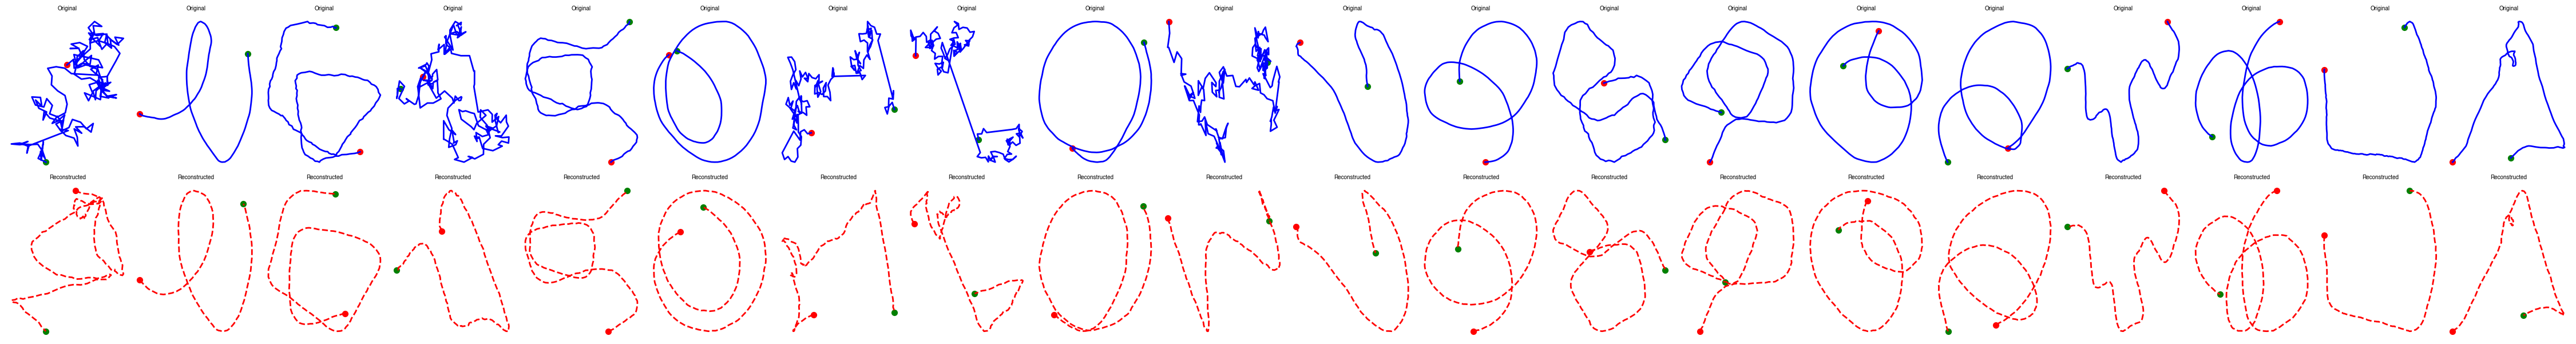

In [49]:
CCL.plot_reconstructions(triplet_model, train_loader, n_input_feats=4)

(<Axes: >, <Axes: >)

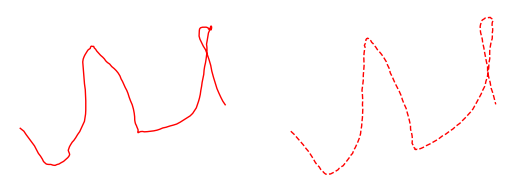

In [50]:
fig, ax= plt.subplots(ncols=2)

CCL.plot_specific_reconstruction(triplet_model, test_loader,color='red', 
                             fifi=True, target_obj_id='2025-11-16_cast_and_surge_constantwind_23769',
                            ax1 = ax[0], ax2 = ax[1])



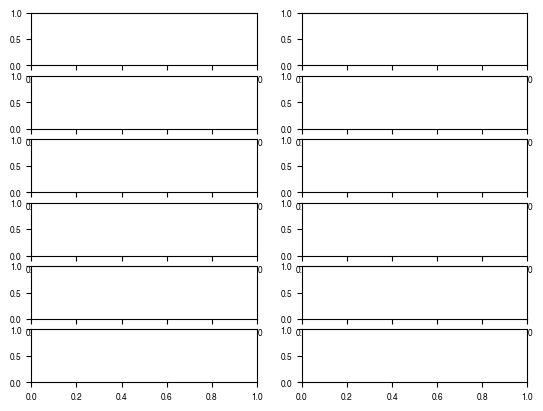

In [51]:
fig, ax= plt.subplots(nrows=6,ncols=2)

ax[0,0] = layout.axes[('A1', 'ai1')]
ax[1,0] = layout.axes[('A1', 'ai2')]
ax[2,0] = layout.axes[('A1', 'ai3')]
ax[3,0] = layout.axes[('A1', 'ai4')]
ax[4,0] = layout.axes[('A1', 'ai5')]
ax[5,0] = layout.axes[('A1', 'ai6')]

ax[0,1] = layout.axes[('A2', 'ao1')]
ax[1,1] = layout.axes[('A2', 'ao2')]
ax[2,1] = layout.axes[('A2', 'ao3')]
ax[3,1] = layout.axes[('A2', 'ao4')]
ax[4,1] = layout.axes[('A2', 'ao5')]
ax[5,1] = layout.axes[('A2', 'ao6')]


#np.random.seed(42)
#rand_ids = df[df.dataset_name!='brownian'].groupby('dataset_name').apply(lambda d: np.random.choice(d.obj_id_unique.unique())).values

# Example 1: Using the main function random_150ms_to_600ms_constant_turns_6783
#['orangered', 'darkcyan',  'orchid','lime', 'yellow'],
CCL.plot_specific_reconstruction(triplet_model, test_loader,color='orangered', fifi=True,ax1=ax[0,0], ax2 = ax[0,1], target_obj_id='2025-11-16_cast_and_surge_constantwind_23769')
CCL.plot_specific_reconstruction(triplet_model, train_loader,color='darkcyan', fifi=True,ax1=ax[1,0], ax2 = ax[1,1], target_obj_id='2025-11-16_sink_and_circle_constantwind_131_')
CCL.plot_specific_reconstruction(triplet_model, train_loader,color='orchid', fifi=True,ax1=ax[2,0], ax2 = ax[2,1], target_obj_id='random_150ms_to_600ms_constant_turns_6783')
CCL.plot_specific_reconstruction(triplet_model, test_loader,color='#a5cc4cff', fifi=True,ax1=ax[4,0], ax2 = ax[4,1], target_obj_id='levysmooth_9028')
CCL.plot_specific_reconstruction(triplet_model, test_loader, color='#661ac6ff', fifi=True,ax1=ax[5,0], ax2 = ax[5,1],target_obj_id='run_and_tumble_959')
CCL.plot_specific_reconstruction(triplet_model, train_loader,color='#dfa45cff', fifi=True,ax1=ax[3,0], ax2 = ax[3,1], target_obj_id='brownian_6465')

layout.append_figure_to_layer(layout.figures['A1'], 'A1', cleartarget=True)
layout.append_figure_to_layer(layout.figures['A2'], 'A2', cleartarget=True)


In [ ]:
#layout.write_svg('test.svg')

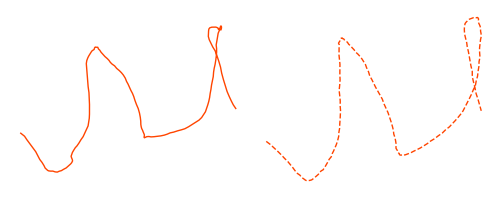

Plot saved as 'reconstruction_obj_2025-11-16_cast_and_surge_constantwind_23769.svg'


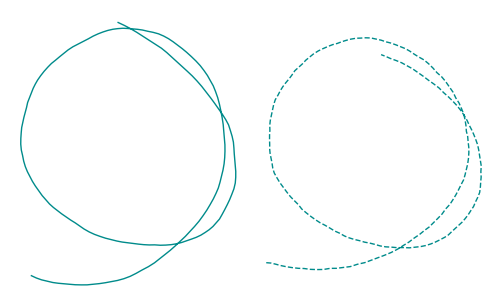

Plot saved as 'reconstruction_obj_2025-11-16_sink_and_circle_constantwind_131_.svg'


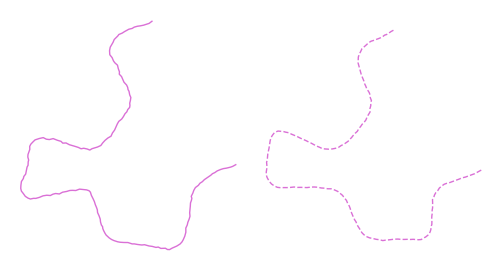

Plot saved as 'reconstruction_obj_random_150ms_to_600ms_constant_turns_6783.svg'


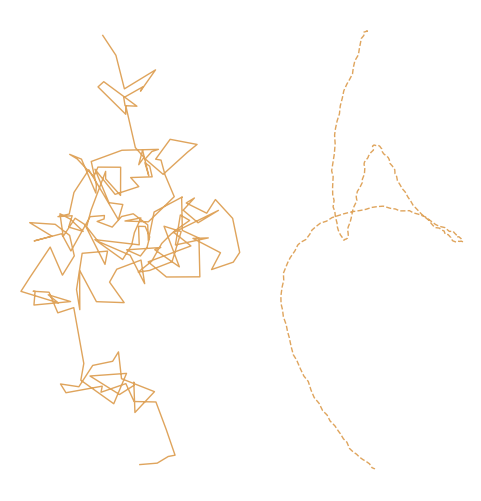

Plot saved as 'reconstruction_obj_brownian_6465.svg'


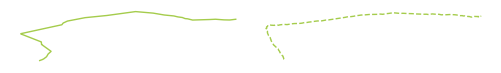

Plot saved as 'reconstruction_obj_levysmooth_9028.svg'


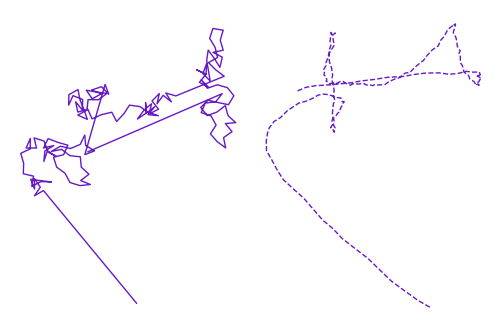

Plot saved as 'reconstruction_obj_run_and_tumble_959.svg'


In [52]:
# Example 1: Using the main function random_150ms_to_600ms_constant_turns_6783
#['orangered', 'darkcyan',  'orchid','lime', 'yellow'],
CCL.plot_specific_reconstruction(triplet_model, test_loader,color='orangered', fifi=False, target_obj_id='2025-11-16_cast_and_surge_constantwind_23769')
CCL.plot_specific_reconstruction(triplet_model, train_loader,color='darkcyan', fifi=False, target_obj_id='2025-11-16_sink_and_circle_constantwind_131_')
CCL.plot_specific_reconstruction(triplet_model, train_loader,color='orchid', fifi=False, target_obj_id='random_150ms_to_600ms_constant_turns_6783')
CCL.plot_specific_reconstruction(triplet_model, train_loader,color='#dfa45cff', fifi=False, target_obj_id='brownian_6465')
CCL.plot_specific_reconstruction(triplet_model, test_loader,color='#a5cc4cff', fifi=False, target_obj_id='levysmooth_9028')
CCL.plot_specific_reconstruction(triplet_model, test_loader, color='#661ac6ff', fifi=False,target_obj_id='run_and_tumble_959')
##levysmooth_8412, 9082

Object ID 2025-01-06_sink_and_circle_vel_6_782 not found in test data.


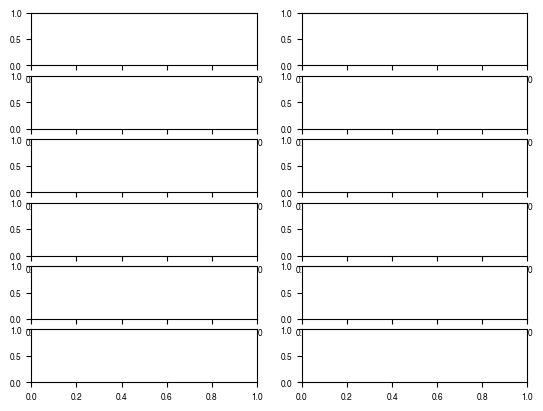

In [53]:
fig, ax= plt.subplots(nrows=6,ncols=2)
ax[0,0] = layout.axes[('C2', 'c_t1')]
ax[1,0] = layout.axes[('C2', 'c_t2')]
ax[2,0] = layout.axes[('C2', 'c_t3')]

ax[0,1] = layout.axes[('C2', 'c_t4')]
ax[1,1] = layout.axes[('C2', 'c_t5')]
ax[2,1] = layout.axes[('C2', 'c_t6')]


CCL.plot_specific_reconstruction(triplet_model, train_loader_cfd_uns_casting,color='k', fifi=True,ax1=ax[0,0], ax2 = ax[0,0], target_obj_id='2025-01-03_cast_and_surge_vel_4_441')
CCL.plot_specific_reconstruction(triplet_model, train_loader_cfd_uns_casting,color='k', fifi=True,ax1=ax[1,0], ax2=ax[1,0], target_obj_id='2025-01-03_cast_and_surge_vel_2_914')
CCL.plot_specific_reconstruction(triplet_model, train_loader_cfd_uns_casting,color='k',  fifi=True,ax1=ax[2,0], ax2 = ax[2,0], target_obj_id='2025-01-03_cast_and_surge_vel_1_557')

CCL.plot_specific_reconstruction(triplet_model, train_loader_cfd_uns_circle,color='k',fifi=True,ax1=ax[0,1], ax2 = ax[0,1], target_obj_id='2025-01-06_sink_and_circle_vel_6_782')
CCL.plot_specific_reconstruction(triplet_model, train_loader_cfd_uns_circle,color='k',fifi=True,ax1=ax[1,1], ax2=ax[1,1], target_obj_id='2025-01-06_sink_and_circle_vel_1_473')
CCL.plot_specific_reconstruction(triplet_model, train_loader_cfd_uns_circle,color='k', fifi=True,ax1=ax[2,1], ax2 = ax[2,1],  target_obj_id='2025-01-06_sink_and_circle_vel_4_743')


layout.append_figure_to_layer(layout.figures['C2'], 'C2', cleartarget=True)


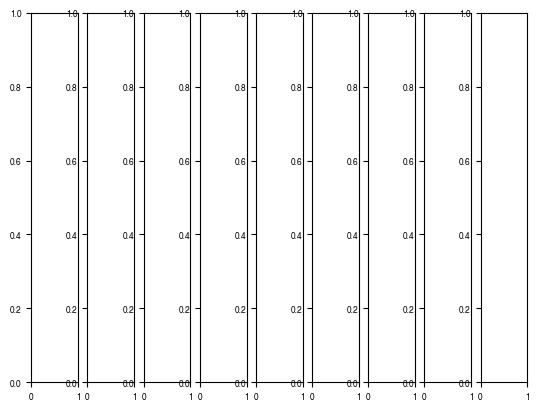

In [54]:
fig, ax= plt.subplots(ncols=9)
ax[0] = layout.axes[('D2', 'd1a')]
ax[1] = layout.axes[('D2', 'd1b')]
ax[2] = layout.axes[('D2', 'd1c')]

ax[3] = layout.axes[('D2', 'd2a')]
ax[4] = layout.axes[('D2', 'd2b')]
ax[5] = layout.axes[('D2', 'd2c')]


ax[6] = layout.axes[('D2', 'd3a')]
ax[7] = layout.axes[('D2', 'd3b')]
ax[8] = layout.axes[('D2', 'd3c')]


CCL.plot_specific_reconstruction(triplet_model, train_loader_unifying_lam,color='k', fifi=True,ax1=ax[0], ax2 = ax[0], target_obj_id='5_laminar')
CCL.plot_specific_reconstruction(triplet_model, train_loader_unifying_lam,color='k', fifi=True,ax1=ax[1], ax2=ax[1], target_obj_id='183_laminar')
CCL.plot_specific_reconstruction(triplet_model, train_loader_unifying_lam,color='k',  fifi=True,ax1=ax[2], ax2 = ax[2], target_obj_id='3_laminar')

CCL.plot_specific_reconstruction(triplet_model, train_loader_unifying_uns,color='k',fifi=True,ax1=ax[3], ax2 = ax[3], target_obj_id='241_unsteady')
CCL.plot_specific_reconstruction(triplet_model, train_loader_unifying_uns,color='k',fifi=True,ax1=ax[4], ax2=ax[4], target_obj_id='362_unsteady')
CCL.plot_specific_reconstruction(triplet_model, train_loader_unifying_uns,color='k', fifi=True,ax1=ax[5], ax2 = ax[5],  target_obj_id='348_unsteady')


CCL.plot_specific_reconstruction(triplet_model,train_loader_unifying_nw,color='k',fifi=True,ax1=ax[6], ax2 = ax[6], target_obj_id='462_stillair')
CCL.plot_specific_reconstruction(triplet_model, train_loader_unifying_nw,color='k',fifi=True,ax1=ax[7], ax2=ax[7], target_obj_id='551_stillair')
CCL.plot_specific_reconstruction(triplet_model, train_loader_unifying_nw,color='k', fifi=True,ax1=ax[8], ax2 = ax[8],  target_obj_id='496_stillair')


layout.append_figure_to_layer(layout.figures['D2'], 'D2', cleartarget=True)


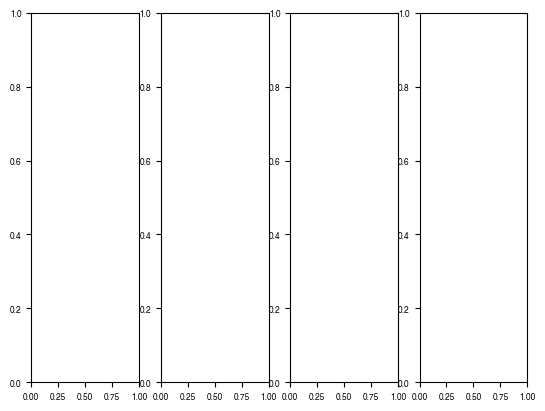

In [55]:
fig, ax= plt.subplots(ncols=4)
ax[0] = layout.axes[('E2', 'e1a')]
ax[1] = layout.axes[('E2', 'e1b')]
ax[2] = layout.axes[('E2', 'e1c')]
ax[3] = layout.axes[('E2', 'e1a')]



CCL.plot_specific_reconstruction(triplet_model,  train_loader_steady,color='k', fifi=True,ax1=ax[0], ax2 = ax[0], target_obj_id='11319_20240516_185822')
CCL.plot_specific_reconstruction(triplet_model, train_loader_unsteady,color='k', fifi=True,ax1=ax[1], ax2=ax[1], target_obj_id='13155_20240111_160822')
CCL.plot_specific_reconstruction(triplet_model, train_loader_lam,color='k',  fifi=True,ax1=ax[2], ax2 = ax[2], target_obj_id='1306_20220926_173927')
CCL.plot_specific_reconstruction(triplet_model,  train_loader_nw,color='k',fifi=True,ax1=ax[3], ax2 = ax[3], target_obj_id='1205_20220814_165127')

layout.append_figure_to_layer(layout.figures['E2'], 'E2', cleartarget=True)

# Plot Latent Space Pca

In [56]:


def plot_latent_space_with_labels(model, test_loader, labels=None, reduce='PCA', KDE=True, KDE_test=True,
                                 n_feats=100, path='output.svg', plotting_labels=None,
                                 train_colors=None, real_data_loaders=None, 
                                 real_data_labels_list=None, real_colors_list=None, 
                                 ax=None, markers=None, alpha_list=None, sizes_list=None,
                                 legend_loc='best'):
    """
    Plot latent space visualization with customizable training data colors and 
    support for multiple real data loaders.
    
    Args:
        model: Trained model
        test_loader: DataLoader for training/test data
        labels: Labels for training data (optional, for color mapping)
        train_colors: List of colors for training data classes
        real_data_loaders: List of DataLoaders for real/comparison datasets
        real_colors_list: List of color specifications for each real dataset
        markers: List of markers for each real dataset
        alpha_list: List of alpha values for each real dataset
        sizes_list: List of point sizes for each real dataset
        legend_loc: Location for legend
    """
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    model.eval()
    
    # Extract latent vectors for training data
    train_latent_vectors = []
    train_true_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            if len(batch) == 3:
                data, label, _ = batch
            elif len(batch) == 2:
                data, label = batch
            else:
                raise ValueError(f"Unexpected batch format")
            
            mu, logvar = model.encode(data)
            train_latent_vectors.append(mu.cpu().numpy())
            train_true_labels.extend(label.cpu().numpy())
    
    if len(train_latent_vectors) > 0:
        train_latent_vectors = np.vstack(train_latent_vectors)
        train_true_labels = np.array(train_true_labels)
    
    # Apply dimensionality reduction to training data
    if reduce == 'PCA':
        from sklearn.decomposition import PCA
        reducer = PCA(n_components=2)
        train_latent_reduced = reducer.fit_transform(train_latent_vectors[:, :n_feats])
        print(f'Using PCA, explained variance: {reducer.explained_variance_ratio_}')
    elif reduce == 'UMAP':
        import umap
        reducer = umap.UMAP(n_components=2, random_state=42)
        train_latent_reduced = reducer.fit_transform(train_latent_vectors)
    elif reduce == 't-SNE':
        from sklearn.manifold import TSNE
        reducer = TSNE(n_components=2, random_state=42, perplexity=30)
        train_latent_reduced = reducer.fit_transform(train_latent_vectors)
    
    # Plot training data with custom colors
    unique_train_labels = np.unique(train_true_labels)
    
    if train_colors is not None:
        # Map labels to provided colors
        label_to_color = {}
        for i, label in enumerate(unique_train_labels):
            if i < len(train_colors):
                label_to_color[label] = train_colors[i]
            else:
                # Fallback to colormap if not enough colors provided
                cmap = plt.cm.tab20
                label_to_color[label] = cmap(i % 20)
        
        # Plot training data
        if KDE:
            # Plot KDE for each training class
            for label in unique_train_labels:
                mask = train_true_labels == label
                if np.sum(mask) > 0:
                    color = label_to_color[label]
                    
                    # Get class name for legend
                    class_name = f'Class {label}'
                    if plotting_labels is not None and label < len(plotting_labels):
                        class_name = plotting_labels[label]
                    
                    sns.kdeplot(
                        x=train_latent_reduced[mask, 0],
                        y=train_latent_reduced[mask, 1],
                        levels=5, thresh=0.05, fill=True, alpha=0.2,
                        color=color,
                        label=class_name,
                        legend=False, ax=ax
                    )

        else:
            # Scatter plot with custom colors
            train_point_colors = [label_to_color[label] for label in train_true_labels]
            scatter = ax.scatter(
                train_latent_reduced[:, 0], train_latent_reduced[:, 1],
                c=train_point_colors, alpha=0.7, s=20,
                edgecolors='k', linewidth=0.5
            )
    else:
        # Default plotting without custom colors
        if KDE:
            sns.kdeplot(
                x=train_latent_reduced[:, 0],
                y=train_latent_reduced[:, 1],
                hue=train_true_labels,
                levels=5, thresh=0.05, fill=True, alpha=0.2,
                palette='viridis',
                legend=False, ax=ax
            )
        else:
            scatter = ax.scatter(
                train_latent_reduced[:, 0], train_latent_reduced[:, 1],
                c=train_true_labels, cmap='viridis', alpha=0.7, s=20,
                edgecolors='k', linewidth=0.5
            )
    
    # Plot multiple real datasets
    if real_data_loaders is not None:
        if not isinstance(real_data_loaders, list):
            real_data_loaders = [real_data_loaders]
        
        # Set defaults for optional parameters
        if real_colors_list is None:
            real_colors_list = [None] * len(real_data_loaders)

        
        if real_data_labels_list is None:
            real_data_labels_list = [None] * len(real_data_loaders)
        
        # Create legend handles for real datasets
        real_legend_handles = []
        
        # Process each real dataset
        for i, (real_loader, colors, labels) in enumerate(zip(
            real_data_loaders, real_colors_list, real_data_labels_list,
        )):
            
            # Extract latent vectors for this real dataset
            real_latent_vectors = []
            real_true_labels = []
            
            with torch.no_grad():
                for batch in real_loader:
                    if len(batch) == 3:
                        data, label, _ = batch
                    elif len(batch) == 2:
                        data, label = batch
                    else:
                        raise ValueError(f"Unexpected batch format")
                    
                    mu, logvar = model.encode(data)
                    real_latent_vectors.append(mu.cpu().numpy())
                    if labels is None:
                        real_true_labels.extend(label.cpu().numpy())
            
            if len(real_latent_vectors) > 0:
                real_latent_vectors = np.vstack(real_latent_vectors)
                
                # Transform using the same reducer
                real_latent_reduced = reducer.transform(real_latent_vectors[:, :n_feats])
                
                # Get dataset name for legend
                dataset_name = f'Dataset {i+1}'
                if isinstance(real_data_labels_list[i], str):
                    dataset_name = real_data_labels_list[i]
                
                # Plot this dataset
                if colors is not None:
                    if isinstance(colors, (list, np.ndarray)) and len(colors) == len(real_latent_reduced):
                        # colors is an array of colors for each point
                        #cmap_real = colors
                        from matplotlib import colors as clrs
                        divnorm = clrs.TwoSlopeNorm(vmin=0.1, vcenter=0.25, vmax=0.4)
            
                        if KDE_test==True:
                            sns.kdeplot(
                                    x=real_latent_reduced[:, 0], 
                                    y=real_latent_reduced[:, 1],
                                    #hue=train_true_labels,
                                    levels=5, thresh=0.05, fill=True, alpha=0.2,
                                    color='k',
                                    legend=False, ax=ax
                                )
                        else:              
                            scatter_real = ax.scatter(
                                real_latent_reduced[:, 0], real_latent_reduced[:, 1],
                                #c=cmap_real, cmap="coolwarm", norm=divnorm,
                                c=colors, cmap="coolwarm", norm=divnorm,
                                alpha=0.7, s=1,
                                edgecolors=None, linewidth=0,
                            )

                    else:
                        if KDE_test == True:
                            sns.kdeplot(
                                x=real_latent_reduced[:, 0], 
                                y=real_latent_reduced[:, 1],
                                #hue=train_true_labels,
                                levels=5, thresh=0.05, fill=True, alpha=0.2,
                                color='k',
                                legend=False, ax=ax
                            )
                               
                        else:
                            # colors is a single color
                            scatter_real = ax.scatter(
                               real_latent_reduced[:, 0], real_latent_reduced[:, 1],
                               c=colors, alpha=0.7, s=1,
                               edgecolors=None, linewidth=0,
                            )
                       
                else:
                    # Default coloring
                    scatter_real = ax.scatter(
                        real_latent_reduced[:, 0], real_latent_reduced[:, 1],
                        c=colors, alpha=0.7, s=1,
                        edgecolors=None, linewidth=0,
                    )

    ax.set_aspect('equal')
    ax.axis('off')
    # Add legend
    handles, labels_legend = ax.get_legend_handles_labels()
    if handles:  # Only add legend if there are handles
        ax.legend(handles=handles, loc=legend_loc, framealpha=0.7)
    
    plt.tight_layout()
    return ax



# Training Data KDEs

Using PCA, explained variance: [0.25978923 0.23014313]


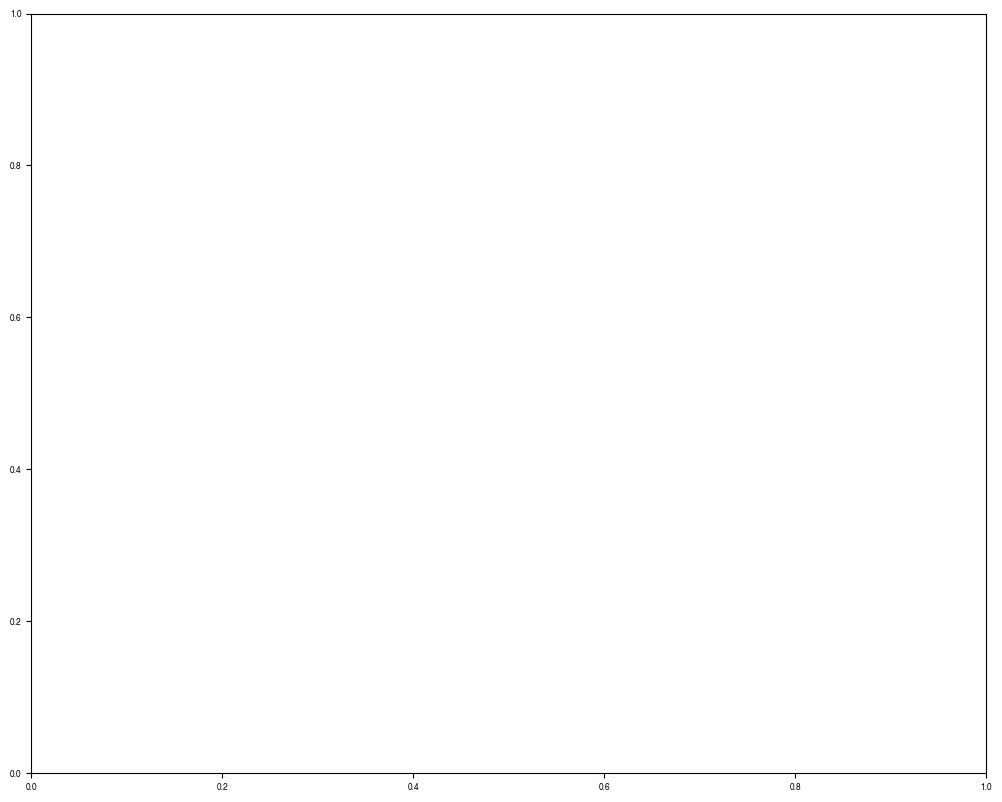

In [57]:
# Your specific case with training colors
fig, ax = plt.subplots(figsize=(10, 8))
ax = layout.axes[('Z', 'z1')]

ax = plot_latent_space_with_labels(
    model=triplet_model,
    test_loader=train_loader,
    train_colors=['orangered', 'darkcyan', 'orchid', '#dfa45cff', '#a6cd4eff', 'darkviolet'],
    reduce='PCA',
    KDE=True, KDE_test = False,
    real_data_loaders=None,
    real_colors_list=None, 
    real_data_labels_list=None, 
    ax=ax
)

 
layout.append_figure_to_layer(layout.figures['Z'], 'Z', cleartarget=True)

# Real Fly Data

Using PCA, explained variance: [0.25978917 0.2301431 ]


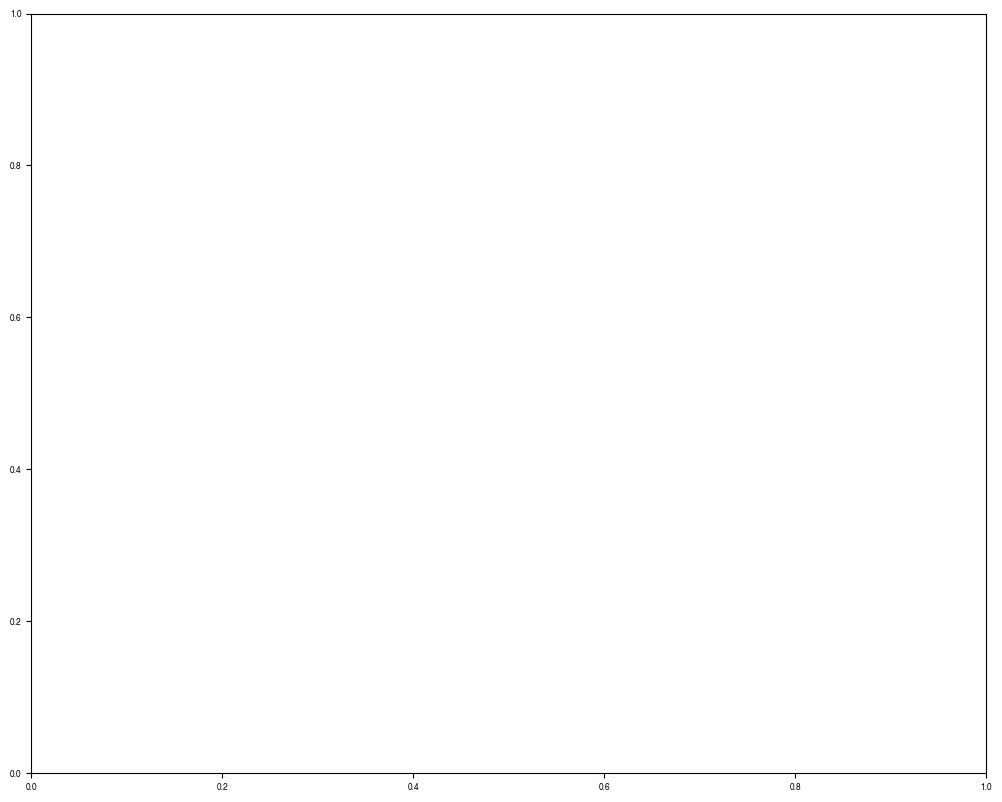

In [58]:
# Your specific case with training colors
fig, ax = plt.subplots(figsize=(10, 8))
ax = layout.axes[('B', 'b1')]

ax = plot_latent_space_with_labels(
    model=triplet_model,
    test_loader=train_loader,
    train_colors=['orangered', 'darkcyan', 'orchid', '#dfa45cff', '#a6cd4eff', 'darkviolet'],
    reduce='PCA',
    KDE=True, KDE_test = False,
    real_data_loaders=[train_loader_lam,train_loader_nw],  # Your laminar/still air loader
    real_colors_list=[y_train_lam_color,y_train_nw_color],  # Your colors array
    real_data_labels_list=['Laminar','Still Air'],  # Dataset name
    ax=ax
)

 
layout.append_figure_to_layer(layout.figures['B'], 'B', cleartarget=True)

Using PCA, explained variance: [0.25978914 0.230143  ]


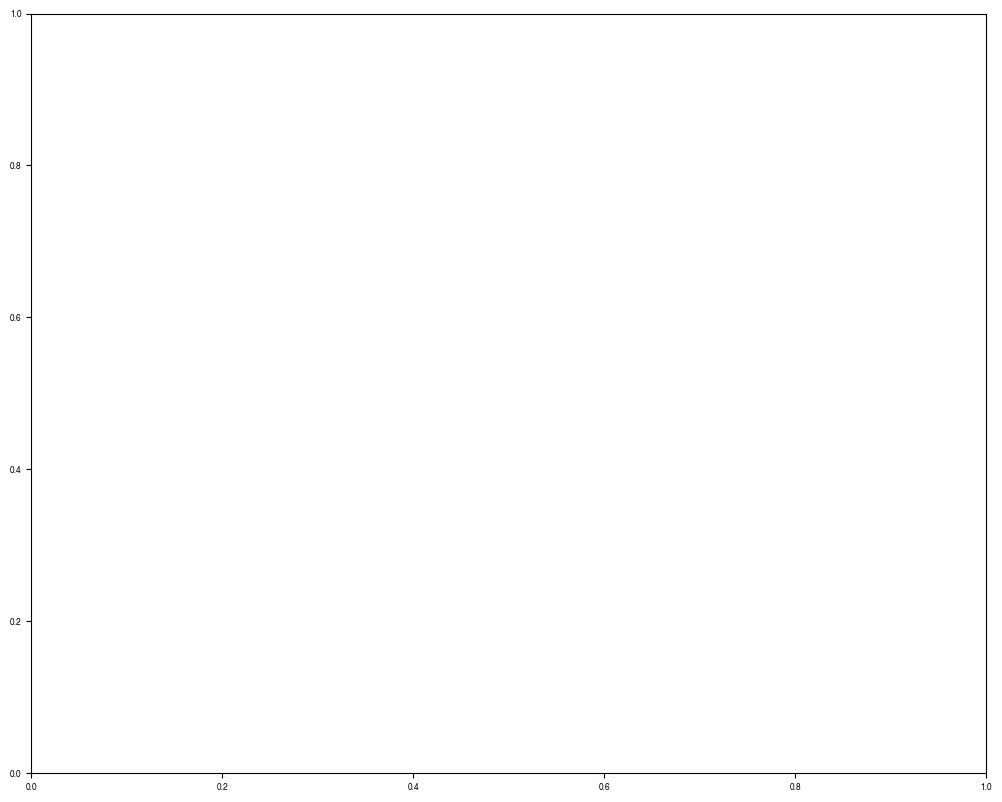

In [59]:
# Your specific case with training colors
fig, ax = plt.subplots(figsize=(10, 8))
ax = layout.axes[('B', 'b2')]

ax = plot_latent_space_with_labels(
    model=triplet_model,
    test_loader=train_loader,
    train_colors=['orangered', 'darkcyan', 'orchid', '#dfa45cff', '#a6cd4eff', 'darkviolet'],
    reduce='PCA',KDE_test = False,
    KDE=True,
    real_data_loaders=[train_loader_steady,train_loader_unsteady],  # Your laminar/still air loader
    real_colors_list=[y_train_steady_color,y_train_unsteady_color],  # Your colors array
    real_data_labels_list=['Steady', 'Unsteady'],  # Dataset name
    ax=ax
)

 
layout.append_figure_to_layer(layout.figures['B'], 'B', cleartarget=True)

# CFD Sims

Using PCA, explained variance: [0.25978935 0.23014319]


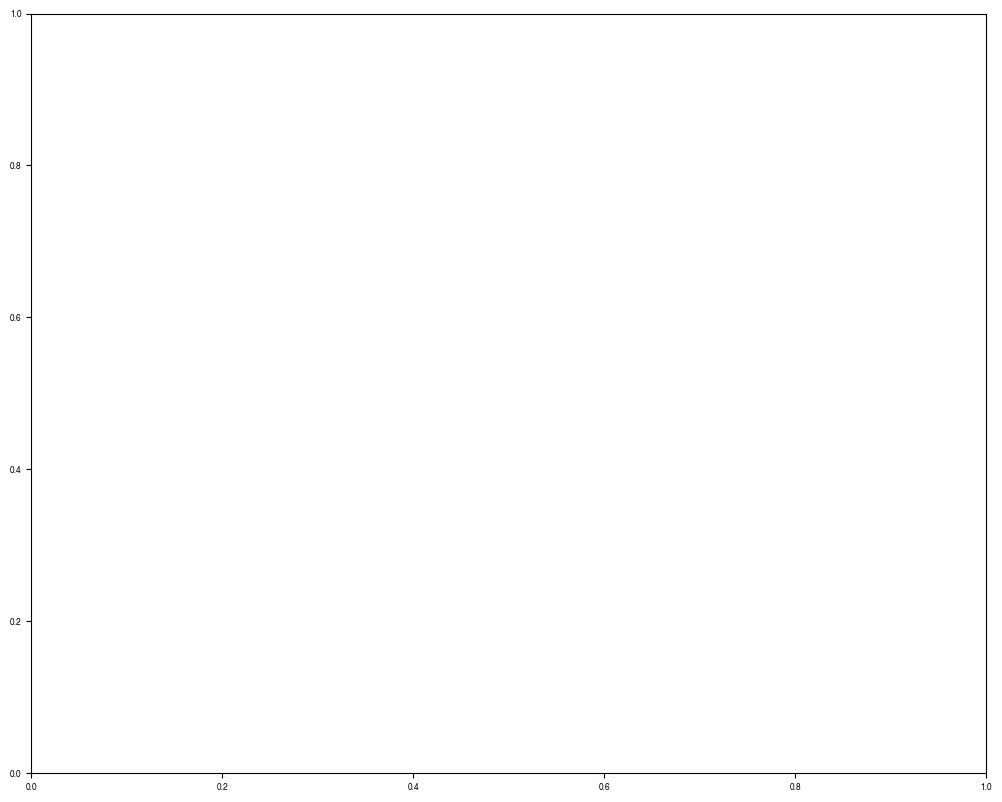

In [60]:
# Your specific case with training colors
fig, ax = plt.subplots(figsize=(10, 8))
ax = layout.axes[('C', 'c1')]

ax = plot_latent_space_with_labels(
    model=triplet_model,
    test_loader=train_loader,
    train_colors=['orangered', 'darkcyan', 'orchid', '#dfa45cff', '#a6cd4eff', 'darkviolet'],
    reduce='PCA',KDE_test = True,
    KDE=True,
    real_data_loaders=[train_loader_cfd_uns_circle],  # Your laminar/still air loader
    real_colors_list=[y_train_cfd_uns_circle],  # Your colors array
    real_data_labels_list=['Laminar','Still Air'],  # Dataset name
    ax=ax
)

 
layout.append_figure_to_layer(layout.figures['C'], 'C', cleartarget=True)


Using PCA, explained variance: [0.25978932 0.23014303]


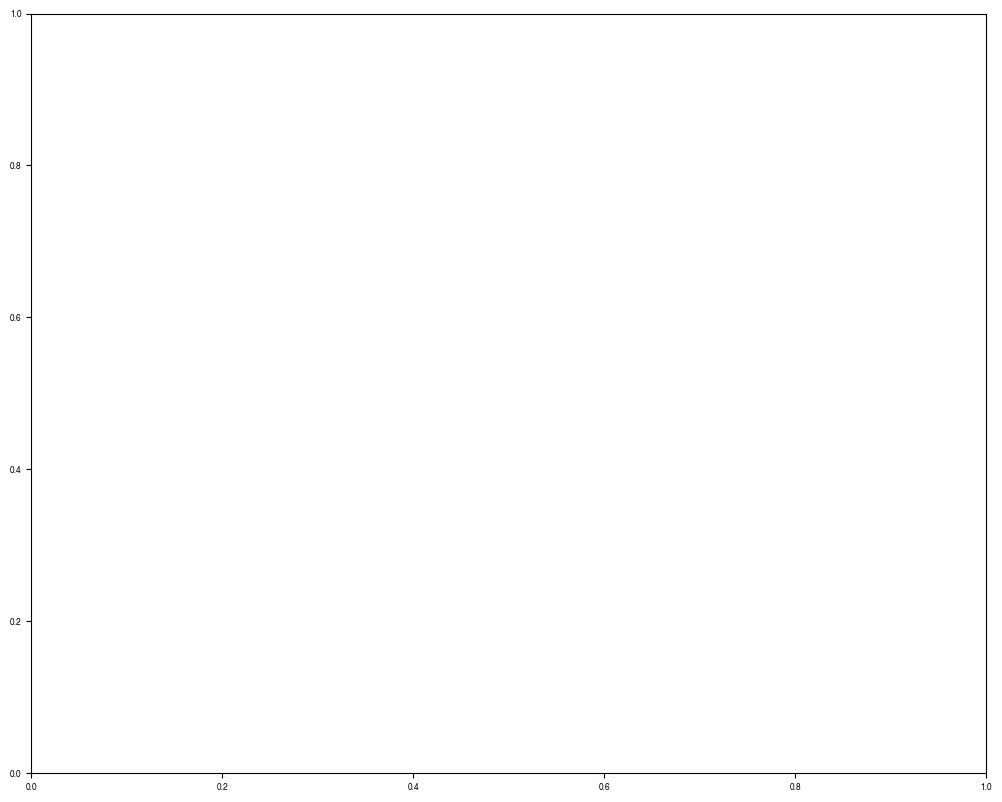

In [61]:
# Your specific case with training colors
fig, ax = plt.subplots(figsize=(10, 8))
ax = layout.axes[('C', 'c2')]

ax = plot_latent_space_with_labels(
    model=triplet_model,
    test_loader=train_loader,
    train_colors=['orangered', 'darkcyan', 'orchid', '#dfa45cff', '#a6cd4eff', 'darkviolet'],
    reduce='PCA',KDE_test = True,
    KDE=True,
    real_data_loaders=[train_loader_cfd_uns_casting],  # Your laminar/still air loader
        real_colors_list=[y_train_cfd_uns_casting_color],  # Your colors array
    real_data_labels_list=['Laminar','Still Air'],  # Dataset name
    ax=ax
)

 
layout.append_figure_to_layer(layout.figures['C'], 'C', cleartarget=True)


# Unifying

Using PCA, explained variance: [0.25978923 0.23014313]


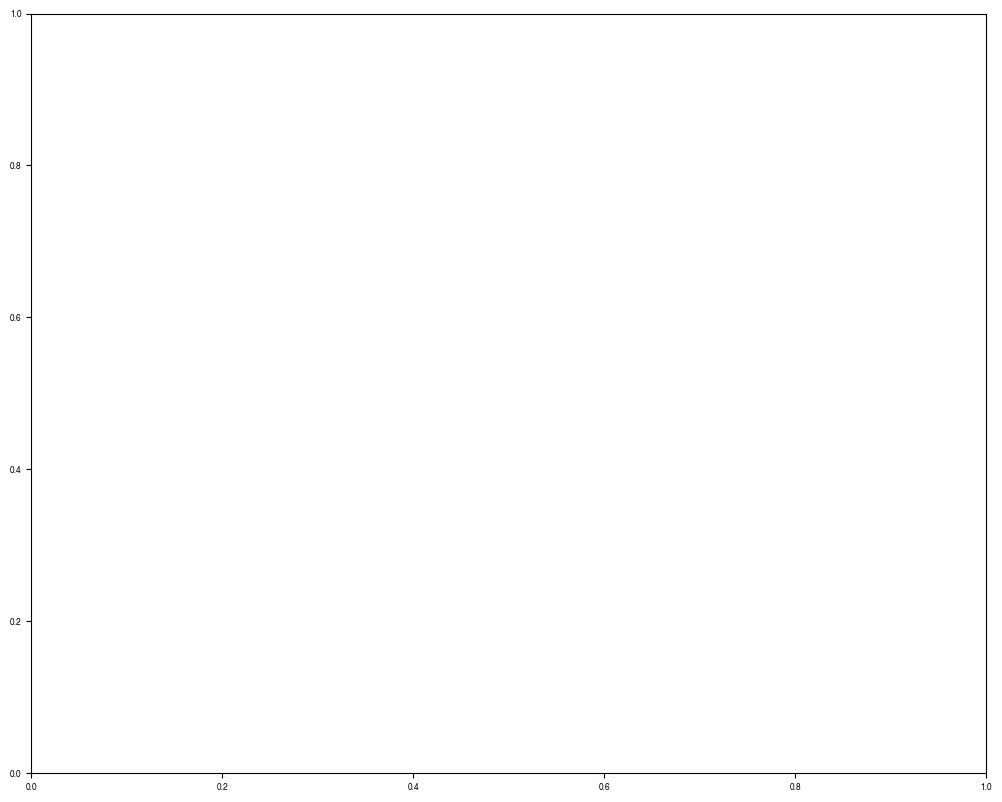

In [62]:
# Your specific case with training colors
fig, ax = plt.subplots(figsize=(10, 8))
ax = layout.axes[('D1', 'd1')]

ax = plot_latent_space_with_labels(
    model=triplet_model,
    test_loader=train_loader,
    train_colors=['orangered', 'darkcyan', 'orchid', '#dfa45cff', '#a6cd4eff', 'darkviolet'],
    reduce='PCA',KDE_test = True,
    KDE=True,
    real_data_loaders=[train_loader_unifying_lam],  # Your laminar/still air loader
        real_colors_list=[y_train_unifying_lam_color],  # Your colors array
    real_data_labels_list=['Laminar','Still Air'],  # Dataset name
    ax=ax
)

 
layout.append_figure_to_layer(layout.figures['D1'], 'D1', cleartarget=True)

Using PCA, explained variance: [0.25978917 0.23014304]


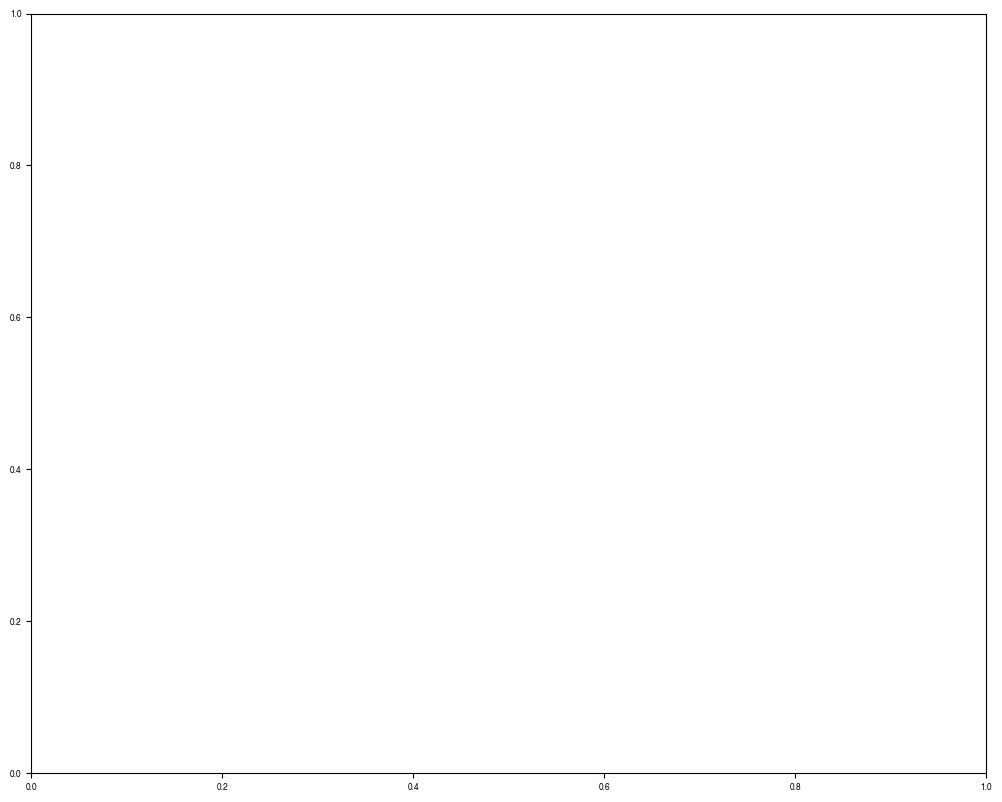

In [63]:
# Your specific case with training colors
fig, ax = plt.subplots(figsize=(10, 8))
ax = layout.axes[('D1', 'd2')]

ax = plot_latent_space_with_labels(
    model=triplet_model,
    test_loader=train_loader,
    train_colors=['orangered', 'darkcyan', 'orchid', '#dfa45cff', '#a6cd4eff', 'darkviolet'],
    reduce='PCA',KDE_test = True,
    KDE=True,
    real_data_loaders=[train_loader_unifying_uns],  # Your laminar/still air loader
        real_colors_list=[y_train_unifying_uns_color],  # Your colors array
    real_data_labels_list=['Laminar','Still Air'],  # Dataset name
    ax=ax
)

 
layout.append_figure_to_layer(layout.figures['D1'], 'D1', cleartarget=True)

Using PCA, explained variance: [0.2597893  0.23014301]


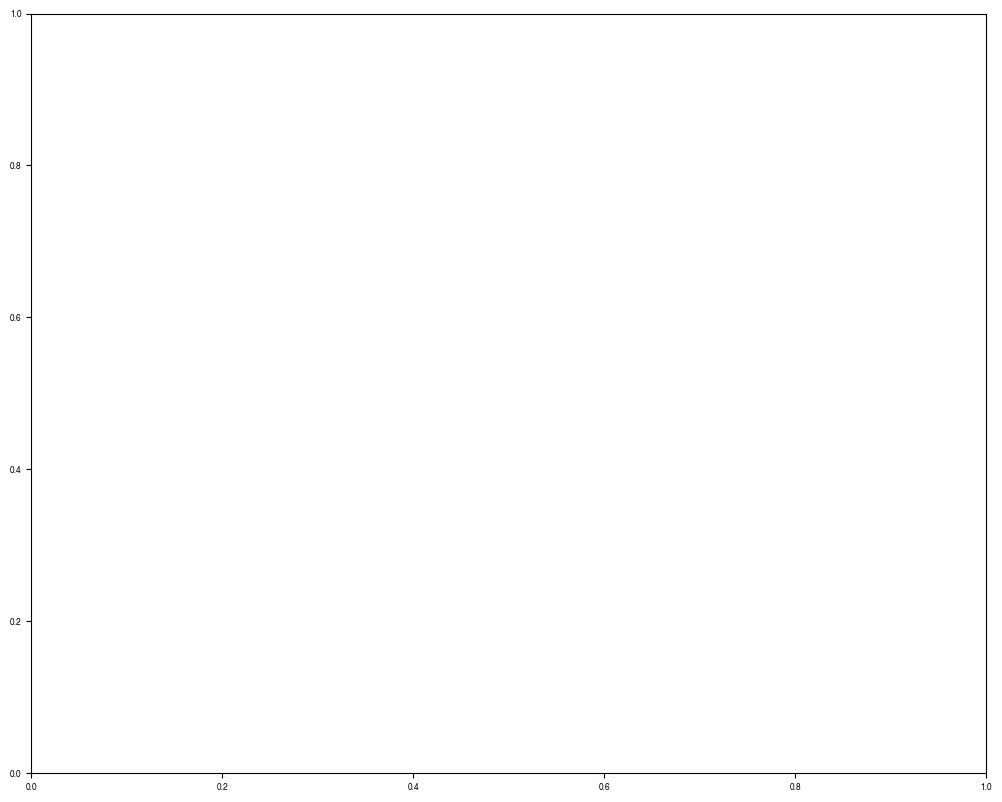

In [83]:
# Your specific case with training colors
fig, ax = plt.subplots(figsize=(10, 8))
ax = layout.axes[('D1', 'd3')]

ax = plot_latent_space_with_labels(
    model=triplet_model,
    test_loader=train_loader,
    train_colors=['orangered', 'darkcyan', 'orchid', '#dfa45cff', '#a6cd4eff', 'darkviolet'],
    reduce='PCA',KDE_test = True,
    KDE=True,
    real_data_loaders=[train_loader_unifying_nw],  # Your laminar/still air loader
        real_colors_list=['purple'],  # Your colors array
    real_data_labels_list=['Laminar','Still Air'],  # Dataset name
    ax=ax
)

 
layout.append_figure_to_layer(layout.figures['D1'], 'D1', cleartarget=True)

In [155]:
from importlib import reload
reload(RF)

<module 'splitflow.RFClassifier' from '/Users/jaleesahoule/Desktop/SPLITFLOW/final_split_flow_gitrepo/SplitFlowOptoTracking_new/Code/RFClassifier.py'>

# Classification

In [161]:

# temp - basic rf
# Use the KNN-based approach
predictions, ood_analysis = RF.predict_with_ood_rejection(
    triplet_model,
    train_loader,test_loader,
    unlabeled_datasets=[train_loader_lam, train_loader_nw, train_loader_steady, train_loader_unsteady, train_loader_steady_sham, train_loader_unsteady_sham, train_loader_cfd_steady_casting,train_loader_cfd_uns_casting,train_loader_cfd_steady_circle,train_loader_cfd_uns_circle, train_loader_unifying_lam, train_loader_unifying_nw,train_loader_unifying_uns],
    #dataset_names=['Laminar', 'NW', 'Steady, Flash', 'Unsteady, Flash', 'Casting, Steady', 'Casting, Unsteady', 'Circling, Steady', 'Circling, Unsteady', 'Unifying, Lam', 'Unifying, NW', 'Unifying, Unsteady'],  # train_loader_cfd_steady_casting,train_loader_cfd_uns_casting,train_loader_cfd_steady_circle,train_loader_cfd_uns_circle, train_loader_unifying_lam, train_loader_unifying_nw,train_loader_unifying_uns],
    dataset_names=['Laminar', 'NW', 'Steady, Flash', 'Unsteady, Flash','Steady, Sham', 'Unsteady, Sham', 'Casting, Steady', 'Casting, Unsteady', 'Circling, Steady', 'Circling, Unsteady', 'Unifying, Lam', 'Unifying, NW', 'Unifying, Unsteady'],
    class_label_dict=class_labels, 
    confidence_threshold=0.6, 
)

# Create and plot the classification matrix
percentage_matrix, count_matrix = RF.create_classification_matrix_with_ood(
    predictions, 
    class_label_dict=class_labels
)



Train loader size: 48000
Number of unlabeled datasets: 13
  Dataset 0: 232 samples
  Dataset 1: 211 samples
  Dataset 2: 145 samples
  Dataset 3: 89 samples
  Dataset 4: 918 samples
  Dataset 5: 1719 samples
  Dataset 6: 500 samples
  Dataset 7: 500 samples
  Dataset 8: 500 samples
  Dataset 9: 500 samples
  Dataset 10: 200 samples
  Dataset 11: 200 samples
  Dataset 12: 200 samples
Random Forest classifier calibrated using temperature scaling.
Processing Laminar with OOD rejection...
Processing NW with OOD rejection...
Processing Steady, Flash with OOD rejection...
Processing Unsteady, Flash with OOD rejection...
Processing Steady, Sham with OOD rejection...
Processing Unsteady, Sham with OOD rejection...
Processing Casting, Steady with OOD rejection...
Processing Casting, Unsteady with OOD rejection...
Processing Circling, Steady with OOD rejection...
Processing Circling, Unsteady with OOD rejection...
Processing Unifying, Lam with OOD rejection...
Processing Unifying, NW with OOD re

In [158]:
print(percentage_matrix.round(2))

                Laminar     NW  Steady, Flash  Unsteady, Flash
Casting Sim       81.03   1.90          81.38            10.11
Circling Sim      12.93  80.09          12.41            58.43
random turns       0.86   9.00           2.07            10.11
brownian           0.00   0.00           0.00             5.62
levy flight        0.00   0.00           0.00             1.12
run and tumble     0.00   0.00           0.00             0.00
OOD/Rejected       5.17   9.00           4.14            14.61


In [ ]:
print(percentage_matrix.round(2))

                Laminar     NW  Steady, Flash  Unsteady, Flash  Steady, Sham  \
Casting Sim       80.79   1.90          81.12            10.00         16.23   
Circling Sim      12.66  79.62          12.59            57.78         48.15   
random turns       0.87   9.00           2.10            10.00         14.05   
brownian           0.00   0.00           0.00             5.56          0.54   
levy flight        0.00   0.00           0.00             1.11          0.76   
run and tumble     0.00   0.00           0.00             0.00          0.00   
OOD/Rejected       5.68   9.48           4.20            15.56         20.26   

                Unsteady, Sham  Casting, Steady  Casting, Unsteady  \
Casting Sim              13.38            88.15              30.99   
Circling Sim             50.84             5.50              31.71   
random turns             15.71             0.76              14.23   
brownian                  1.16             0.00               0.00   
levy flig

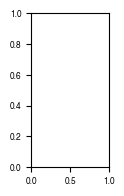

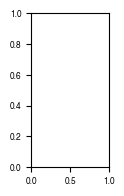

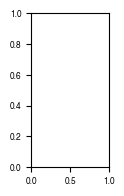

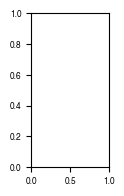

In [159]:
plt.rcParams['font.size'] = 6
# Call the function with your actual data
# Replace with your actual percentage_matrix and count_matrix
fig1, ax_heatmap = plt.subplots(figsize=(1,2))
fig2, ax_ycolorbar = plt.subplots(figsize=(1,2))
fig3, ax_xcolorbar = plt.subplots(figsize=(1,2))
fig4, ax_heatmap_cbar = plt.subplots(figsize=(1,2))
ax_heatmap = layout.axes[('RF1', 'rf1')]
ax_ycolorbar = layout.axes[('CBTRAIN', 'cbtrain')]
ax_xcolorbar = layout.axes[('CBTEST', 'cbtest')] 
ax_heatmap_cbar = layout.axes[('CBHEATMAP', 'cbheatmap')]


ax_heatmap,ax_ycolorbar,ax_xcolorbar,ax_heatmap_cbar  = RF.plot_classification_matrix_with_colorbars(
    percentage_matrix=percentage_matrix[['NW','Unsteady, Flash','Steady, Flash','Laminar',]],  # Your actual data
    count_matrix=count_matrix[['NW','Unsteady, Flash','Steady, Flash','Laminar',]],  # Your actual data
    y_colors=['orangered', 'darkcyan', 'orchid', '#dfa45cff', '#a6cd4eff', 'darkviolet', 'k'],
    x_colors=['#063161d2','#2b75b3ff','#da834dff','#991128d2',], ax1 =ax_heatmap ,ax2=ax_ycolorbar,ax3 = ax_xcolorbar,ax4=ax_heatmap_cbar,
        show_y_labels=False, 
    show_x_labels=False,
    colorbar_width=0.005, heatmap_cmap='gist_gray_r',
    colorbar_border=False,
    figsize=(16, 10),row_order = [0,1,2,4,5,3,6],
    show_percentage_cbar=True,
)

layout.append_figure_to_layer(layout.figures['RF1'], 'RF1', cleartarget=True)#
layout.append_figure_to_layer(layout.figures['CBTRAIN'], 'CBTRAIN', cleartarget=True)
layout.append_figure_to_layer(layout.figures['CBTEST'], 'CBTEST', cleartarget=True)
layout.append_figure_to_layer(layout.figures['CBHEATMAP'], 'CBHEATMAP', cleartarget=True)

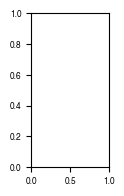

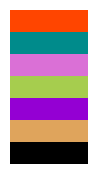

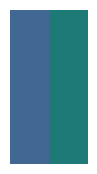

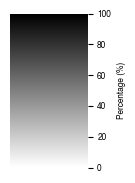

In [163]:
plt.rcParams['font.size'] = 6
# Call the function with your actual data
# Replace with your actual percentage_matrix and count_matrix
fig1, ax_heatmap = plt.subplots(figsize=(1,2))
fig2, ax_ycolorbar = plt.subplots(figsize=(1,2))
fig3, ax_xcolorbar = plt.subplots(figsize=(1,2))
fig4, ax_heatmap_cbar = plt.subplots(figsize=(1,2))

ax_heatmap = layout.axes[('RF2', 'rf2')]


#ax_ycolorbar = layout.axes[('CBTRAIN', 'cbtrain')]
#ax_xcolorbar = layout.axes[('CBTEST', 'cbtest')] 
#ax_heatmap_cbar = layout.axes[('CBHEATMAP', 'cbheatmap')]


ax_heatmap,ax_ycolorbar,ax_xcolorbar,ax_heatmap_cbar  = RF.plot_classification_matrix_with_colorbars(
    percentage_matrix=percentage_matrix[['Circling, Unsteady', 'Casting, Unsteady', ]],  # Your actual data
    count_matrix=count_matrix[['Circling, Unsteady','Casting, Unsteady', ]],  # Your actual data
    y_colors=['orangered', 'darkcyan', 'orchid', '#dfa45cff', '#a6cd4eff', 'darkviolet', 'k'],row_order = [0,1,2,4,5,3,6],
    x_colors=['#0e4075ca','#11736ff2',], ax1 =ax_heatmap ,ax2=ax_ycolorbar,ax3 = ax_xcolorbar,ax4=ax_heatmap_cbar,
        show_y_labels=False, 
    show_x_labels=False,
    colorbar_width=0.005, heatmap_cmap='gist_gray_r',
    colorbar_border=False,
    figsize=(16, 10),
    show_percentage_cbar=True,
)

layout.append_figure_to_layer(layout.figures['RF2'], 'RF2', cleartarget=True)#
#layout.append_figure_to_layer(layout.figures['CBTRAIN'], 'CBTRAIN', cleartarget=True)
#layout.append_figure_to_layer(layout.figures['CBTEST'], 'CBTEST', cleartarget=True)
#layout.append_figure_to_layer(layout.figures['CBHEATMAP'], 'CBHEATMAP', cleartarget=True)

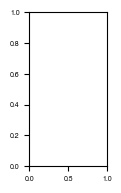

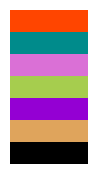

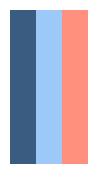

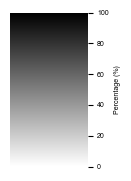

In [164]:
plt.rcParams['font.size'] = 5
# Call the function with your actual data
# Replace with your actual percentage_matrix and count_matrix
fig1, ax_heatmap = plt.subplots(figsize=(1,2))
fig2, ax_ycolorbar = plt.subplots(figsize=(1,2))
fig3, ax_xcolorbar = plt.subplots(figsize=(1,2))
fig4, ax_heatmap_cbar = plt.subplots(figsize=(1,2))

ax_heatmap = layout.axes[('RF3', 'rf3')]


#ax_ycolorbar = layout.axes[('CBTRAIN', 'cbtrain')]
#ax_xcolorbar = layout.axes[('CBTEST', 'cbtest')] 
#ax_heatmap_cbar = layout.axes[('CBHEATMAP', 'cbheatmap')]


ax_heatmap,ax_ycolorbar,ax_xcolorbar,ax_heatmap_cbar  = RF.plot_classification_matrix_with_colorbars(
    percentage_matrix=percentage_matrix[[ 'Unifying, NW','Unifying, Unsteady','Unifying, Lam',]],  # Your actual data
    count_matrix=count_matrix[[ 'Unifying, NW','Unifying, Unsteady','Unifying, Lam',]],  # Your actual data
    y_colors=['orangered', 'darkcyan', 'orchid', '#dfa45cff', '#a6cd4eff', 'darkviolet', 'k'],row_order = [0,1,2,4,5,3,6],
    x_colors=['#06315fca','#83bbf5cb','#ff735bca'], ax1 =ax_heatmap ,ax2=ax_ycolorbar,ax3 = ax_xcolorbar,ax4=ax_heatmap_cbar,
        show_y_labels=False, 
    show_x_labels=False,
    colorbar_width=0.005, heatmap_cmap='gist_gray_r',
    colorbar_border=False,
    figsize=(16, 10),
    show_percentage_cbar=True,
)

layout.append_figure_to_layer(layout.figures['RF3'], 'RF3', cleartarget=True)#
#layout.append_figure_to_layer(layout.figures['CBTRAIN'], 'CBTRAIN', cleartarget=True)
#layout.append_figure_to_layer(layout.figures['CBTEST'], 'CBTEST', cleartarget=True)
#layout.append_figure_to_layer(layout.figures['CBHEATMAP'], 'CBHEATMAP', cleartarget=True)

In [165]:
layout.write_svg('test.svg')

In [148]:
count_matrix.sum()

Laminar                229
NW                     211
Steady, Flash          143
Unsteady, Flash         90
Steady, Sham           918
Unsteady, Sham        1719
Casting, Steady       1055
Casting, Unsteady      555
Circling, Steady      1187
Circling, Unsteady    1153
Unifying, Lam          198
Unifying, NW           198
Unifying, Unsteady     198
dtype: int64